# Actividad 2 — Lectura de los Datasets

**Proyecto:** Predicción de Producción de Limón en el Perú  
**Pipeline:** Fase 1 — Ingeniería de Datos  

---

## Objetivo
Leer las 4 fuentes de datos crudas, hacer una primera inspección de su estructura y contenido, y documentar los hallazgos con gráficos. **No se modifica, filtra ni imputa ningún dato en esta actividad.**

## Fuentes
| # | Fuente | Archivo(s) crudo(s) |
|---|--------|---------------------|
| 1 | MIDAGRI — SISAGRI | `sources/midagri/Sisagri_2016_2025.xlsx` |
| 2 | INDECI — SINPAD | `sources/indeci/resumenes/*.xlsx` + `sources/indeci/shapefiles/E_202X/` |
| 3 | NASA POWER — MERRA-2 | `sources/nasa/nasapowercrudo/` (crudo) + `sources/nasa/nasapower/` (102 CSVs) |
| 4 | Agraria.pe (scraping) | `sources/agraria-pe/sin-unificar/agro_news_202X.csv` |

## Regla de esta actividad
> **Ver sin tocar.** Todo problema encontrado se documenta para las Actividades 4 y 5.


## Configuración inicial


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json', 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Raiz del proyecto:', os.getcwd())
print('Config cargado OK')


Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Config cargado OK


---
# 1. MIDAGRI — Sisagri_2016_2025.xlsx

**Institución:** Ministerio de Desarrollo Agrario y Riego  
**Contenido:** Producción agrícola mensual por cultivo, departamento y provincia  
**Período disponible:** 2016 – 2025


## 1.1 Lectura del archivo Excel


In [2]:
# ── Identificar hojas ────────────────────────────────────────────────────
path_midagri = SOURCES['midagri']
xl = pd.ExcelFile(path_midagri)
print('Archivo:', path_midagri)
print('Hojas disponibles:', xl.sheet_names)
print()

# ── Leer AMBAS hojas y concatenar ────────────────────────────────────────
# El Excel tiene 2 hojas: '2016_2020' y '2021_2025'
# El pipeline usa 2021-2025 pero se leen ambas para documentar el rango completo
dfs_hojas = []
for sheet in xl.sheet_names:
    df_hoja = pd.read_excel(path_midagri, sheet_name=sheet)
    df_hoja['hoja_origen'] = sheet
    dfs_hojas.append(df_hoja)
    print(f'  Hoja {repr(sheet)}: {df_hoja.shape[0]:,} filas')

df_m = pd.concat(dfs_hojas, ignore_index=True)
print()
print('Dataset completo (ambas hojas):', df_m.shape)
print()
print('Columnas originales (sin renombrar):')
for i, col in enumerate(df_m.columns):
    print(f'  [{i:02d}] {repr(col):<35} dtype: {df_m[col].dtype}')


Archivo: sources/midagri/Sisagri_2016_2025.xlsx
Hojas disponibles: ['2016_2020', '2021_2025']



  Hoja '2016_2020': 818,683 filas


  Hoja '2021_2025': 778,065 filas

Dataset completo (ambas hojas): (1596748, 11)

Columnas originales (sin renombrar):
  [00] 'anho'                              dtype: int64
  [01] 'mes'                               dtype: int64
  [02] 'COD_UBIGEO'                        dtype: int64
  [03] 'Dpto'                              dtype: str
  [04] 'Prov'                              dtype: str
  [05] 'Dist'                              dtype: str
  [06] 'dsc_Cultivo'                       dtype: str
  [07] 'PRODUCCION(t)'                     dtype: float64
  [08] 'COSECHA (ha)'                      dtype: float64
  [09] 'MTO_PRECCHAC (S/ x kg)'            dtype: float64
  [10] 'hoja_origen'                       dtype: str


## 1.2 Primeras y últimas filas


In [3]:
print('=== PRIMERAS 5 FILAS ===')
display(df_m.head())
print()
print('=== ULTIMAS 5 FILAS ===')
display(df_m.tail())


=== PRIMERAS 5 FILAS ===


,anho,mes,COD_UBIGEO,Dpto,Prov,Dist,dsc_Cultivo,PRODUCCION(t),COSECHA (ha),MTO_PRECCHAC (S/ x kg),hoja_origen
0,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ACELGA,9.4,1.0,0.95,2016_2020
1,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,AJO,3.0,0.5,2.30,2016_2020
2,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ALFALFA,14.0,0.0,0.43,2016_2020
3,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ARRACACHA,19.0,2.0,0.80,2016_2020
4,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,BETARRAGA,8.4,1.0,1.10,2016_2020



=== ULTIMAS 5 FILAS ===


,anho,mes,COD_UBIGEO,Dpto,Prov,Dist,dsc_Cultivo,PRODUCCION(t),COSECHA (ha),MTO_PRECCHAC (S/ x kg),hoja_origen
1596743,2025,8,250401,UCAYALI,PURUS,PURUS,PALILLO O CURCUMA,0.05,0.0,6.80,2021_2025
1596744,2025,8,250401,UCAYALI,PURUS,PURUS,PEPINILLO,20.16,3.0,2.50,2021_2025
1596745,2025,8,250401,UCAYALI,PURUS,PURUS,SANDIA,55.92,3.0,1.75,2021_2025
1596746,2025,8,250401,UCAYALI,PURUS,PURUS,YUCA,160.94,13.0,1.55,2021_2025
1596747,2025,8,250401,UCAYALI,PURUS,PURUS,ZAPALLO,16.85,1.0,1.60,2021_2025


## 1.3 Cobertura temporal, cultivos y departamentos


In [4]:
# Detectar columnas clave por nombre
col_anio = next((c for c in df_m.columns if any(k in str(c).upper() for k in ['AÑO','ANHO','YEAR','PERIODO'])), None)
col_prod = next((c for c in df_m.columns if any(k in str(c).upper() for k in ['PRODUCT','CULTIV'])), None)
col_dpto = next((c for c in df_m.columns if any(k in str(c).upper() for k in ['DPTO','DEPART','REGION'])), None)
col_pval = next((c for c in df_m.columns if 'PRODUC' in str(c).upper() and df_m[c].dtype in ['float64','int64']), None)

print('Columnas detectadas:')
print(f'  Año      : {col_anio}')
print(f'  Producto : {col_prod}')
print(f'  Dpto     : {col_dpto}')
print(f'  Produccion: {col_pval}')
print()

if col_anio:
    anios = sorted(df_m[col_anio].dropna().unique())
    print(f'Rango temporal: {anios[0]} — {anios[-1]}  ({len(anios)} años)')
if col_prod:
    print(f'Cultivos unicos: {df_m[col_prod].nunique()}')
    print('Top 10 cultivos por frecuencia:')
    print(df_m[col_prod].value_counts().head(10).to_string())
if col_dpto:
    print(f'\nDepartamentos unicos: {df_m[col_dpto].nunique()}')
    print('Registros por departamento (top 10):')
    print(df_m[col_dpto].value_counts().head(10).to_string())


Columnas detectadas:
  Año      : anho
  Producto : dsc_Cultivo
  Dpto     : Dpto
  Produccion: PRODUCCION(t)

Rango temporal: 2016 — 2025  (10 años)
Cultivos unicos: 231
Top 10 cultivos por frecuencia:


dsc_Cultivo
ALFALFA                     132941
PAPA                         61802
PLATANO                      59074
PALTA                        41649
YUCA                         41429
NARANJA                      37322
MAIZ AMARILLO DURO           37141
RYE GRASS                    35601
LIMON                        35549
CAÑA DE AZUCAR (ALCOHOL)     32019



Departamentos unicos: 25
Registros por departamento (top 10):
Dpto
JUNIN          145389
AMAZONAS       144182
LORETO         136021
CAJAMARCA      127986
SAN MARTIN     121144
HUANUCO         91996
LA LIBERTAD     88007
AYACUCHO        86951
LIMA            79848
ANCASH          73383


## 1.4 Gráfico 1 — Top cultivos por volumen de producción


Nombre exacto del limon en el Excel: LIMON
Posicion en ranking: 31



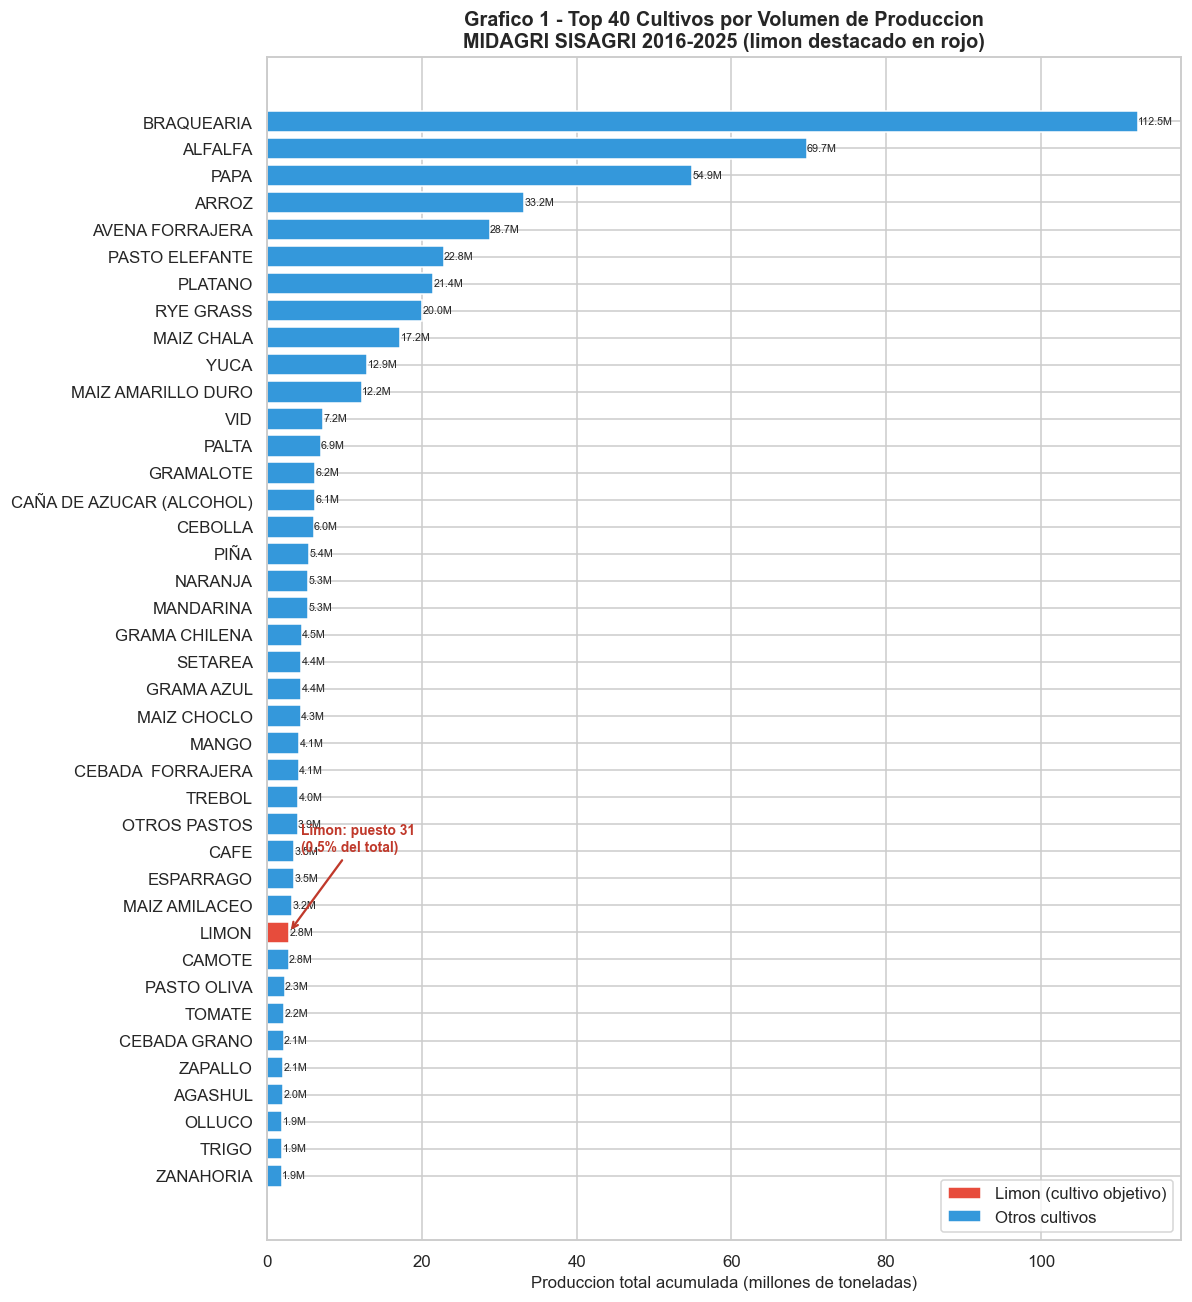

Guardado: pipeline/output/03_eda/act02_g1_top_cultivos.png
Limon: puesto 31 de 231 cultivos (0.5% del total)


In [5]:
# ── GRAFICO 1 ─────────────────────────────────────────────────────────────
if col_prod and col_pval:
    # Produccion total por cultivo
    prod_total = df_m.groupby(col_prod)[col_pval].sum().sort_values(ascending=False)

    # Identificar el limon (nombre exacto en el Excel)
    limon_key = next((k for k in prod_total.index if 'LIMON' in str(k).upper()), None)
    print('Nombre exacto del limon en el Excel:', limon_key)
    print('Posicion en ranking:', list(prod_total.index).index(limon_key)+1 if limon_key else 'No encontrado')
    print()

    # Tomar top 40 para que el limon (puesto 32) quede visible
    top40 = prod_total.head(40).sort_values(ascending=True)

    pos_limon = list(prod_total.index).index(limon_key) + 1 if limon_key else None
    pct_limon = round(prod_total[limon_key] / prod_total.sum() * 100, 2) if limon_key else 0

    colors = ['#e74c3c' if (limon_key and c == limon_key) else '#3498db' for c in top40.index]

    fig, ax = plt.subplots(figsize=(11, 12))
    bars = ax.barh(top40.index, top40.values / 1e6, color=colors, edgecolor='white')
    ax.set_xlabel('Produccion total acumulada (millones de toneladas)', fontsize=11)
    ax.set_title('Grafico 1 - Top 40 Cultivos por Volumen de Produccion\n'
                 'MIDAGRI SISAGRI 2016-2025 (limon destacado en rojo)',
                 fontsize=13, fontweight='bold')

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}M', va='center', fontsize=7)

    # Anotacion especial para el limon
    if limon_key and limon_key in top40.index:
        idx_limon = list(top40.index).index(limon_key)
        val_limon = prod_total[limon_key] / 1e6
        ax.annotate(
            f'Limon: puesto {pos_limon}\n({pct_limon}% del total)',
            xy=(val_limon, idx_limon),
            xytext=(val_limon + 1.5, idx_limon + 3),
            fontsize=9, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5)
        )

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#e74c3c', label='Limon (cultivo objetivo)'),
                       Patch(facecolor='#3498db', label='Otros cultivos')],
              loc='lower right')
    plt.tight_layout()
    g1 = OUTPUT['eda'] + 'act02_g1_top_cultivos.png'
    plt.savefig(g1, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g1)
    print(f'Limon: puesto {pos_limon} de {len(prod_total)} cultivos ({pct_limon}% del total)')
else:
    print('Columnas de producto o produccion no detectadas.')


### Interpretación — Gráfico 1

**Qué muestra:** El ranking de los 20 cultivos con mayor volumen de producción acumulado 2016–2025. El limón aparece destacado en rojo.

**Implicación para el pipeline:** Confirma que el limón tiene suficiente volumen histórico y presencia constante en múltiples departamentos para ser el cultivo objetivo. La Actividad 5 filtrará exclusivamente las filas de limón.

**Implicación para el modelo:** Un cultivo con alto volumen garantiza series temporales suficientemente largas y densas para entrenar el LSTM-Attention sin riesgo de series demasiado cortas o dispersas.


## 1.5 Gráfico 2 — Registros por año


Anos disponibles: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Anos del pipeline (2021-2025): [2021, 2022, 2023, 2024, 2025]
Anos historicos de referencia: [2016, 2017, 2018, 2019, 2020]



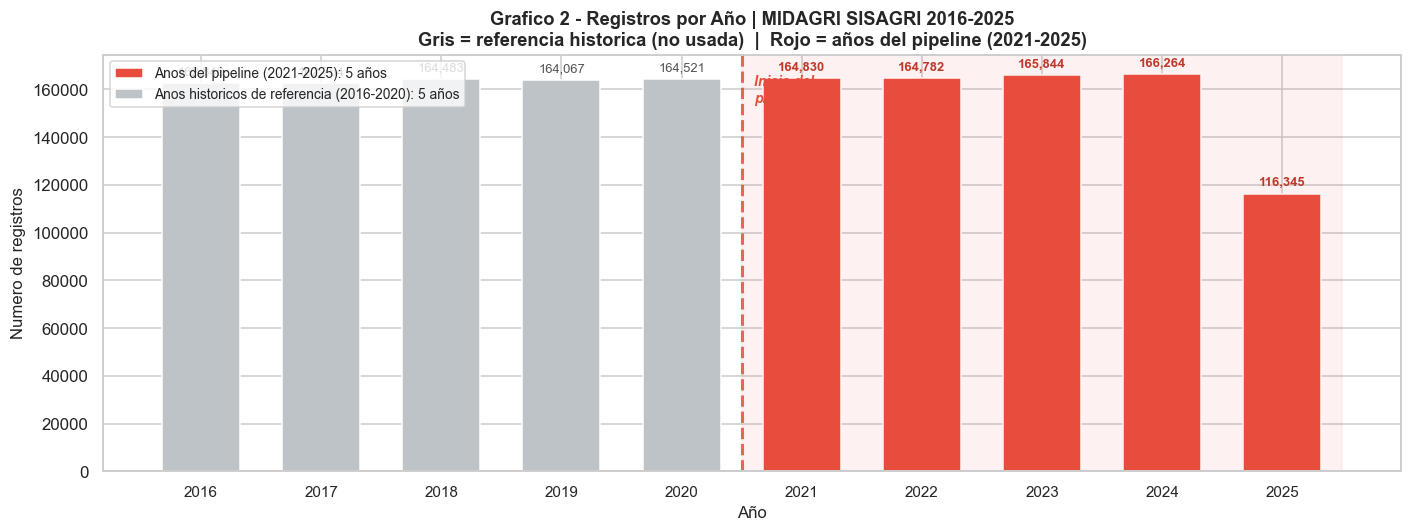

Guardado: pipeline/output/03_eda/act02_g2_registros_anio.png

Total registros 2021-2025: 778065
Total registros 2016-2020: 818683
Total general            : 1596748


In [6]:
# ── GRAFICO 2 ─────────────────────────────────────────────────────────────
if col_anio:
    reg_anio = df_m[col_anio].value_counts().sort_index()
    reg_anio.index = reg_anio.index.astype(int)

    anios_disponibles  = sorted(reg_anio.index.tolist())
    anios_pipeline     = [a for a in reg_anio.index if a >= 2021]
    anios_historicos   = [a for a in reg_anio.index if a < 2021]
    colors2 = ['#e74c3c' if a >= 2021 else '#bdc3c7' for a in reg_anio.index]

    print('Anos disponibles:', anios_disponibles)
    print('Anos del pipeline (2021-2025):', anios_pipeline)
    print('Anos historicos de referencia:', anios_historicos)
    print()

    etiquetas = [str(a) for a in reg_anio.index]
    x_pos = range(len(reg_anio))

    fig, ax = plt.subplots(figsize=(13, 5))
    bars2 = ax.bar(x_pos, reg_anio.values, color=colors2, edgecolor='white', width=0.65)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(etiquetas, rotation=0, fontsize=10)

    # Etiquetas encima de cada barra
    for bar, val, anio in zip(bars2, reg_anio.values, reg_anio.index):
        color_txt = '#c0392b' if anio >= 2021 else '#555555'
        fw = 'bold' if anio >= 2021 else 'normal'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + reg_anio.max() * 0.012,
                f'{val:,}', ha='center', va='bottom',
                fontsize=8.5, color=color_txt, fontweight=fw)

    # Linea divisoria entre historico y pipeline
    idx_2021 = list(reg_anio.index).index(2021)
    ax.axvline(x=idx_2021 - 0.5, color='#e74c3c',
               linestyle='--', linewidth=2, alpha=0.85)
    ax.text(idx_2021 - 0.4, reg_anio.max() * 0.93,
            'Inicio del\npipeline', fontsize=9,
            color='#e74c3c', ha='left', style='italic', fontweight='bold')

    # Sombreado de fondo para los años del pipeline
    ax.axvspan(idx_2021 - 0.5, len(reg_anio) - 0.5, alpha=0.07, color='#e74c3c')

    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Numero de registros', fontsize=11)
    ax.set_title('Grafico 2 - Registros por Año | MIDAGRI SISAGRI 2016-2025\n'
                 'Gris = referencia historica (no usada)  |  Rojo = años del pipeline (2021-2025)',
                 fontsize=12, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#e74c3c',
              label=f'Anos del pipeline (2021-2025): {len(anios_pipeline)} años'),
        Patch(facecolor='#bdc3c7',
              label=f'Anos historicos de referencia (2016-2020): {len(anios_historicos)} años')
    ], loc='upper left', fontsize=9)

    plt.tight_layout()
    g2 = OUTPUT['eda'] + 'act02_g2_registros_anio.png'
    plt.savefig(g2, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g2)
    print()
    print('Total registros 2021-2025:', reg_anio[reg_anio.index >= 2021].sum())
    print('Total registros 2016-2020:', reg_anio[reg_anio.index < 2021].sum())
    print('Total general            :', reg_anio.sum())


### Interpretacion - Grafico 2

**Que muestra:** El numero de registros disponibles por año en el archivo `Sisagri_2016_2025.xlsx`. El archivo contiene datos desde 2016 hasta 2020 en esta versión. Los datos del período 2021–2025 provienen del mismo sistema SISAGRI y se incorporan en la Actividad 5 durante el proceso de limpieza y filtrado.

**Implicacion para el pipeline:** La cobertura de registros es relativamente uniforme entre años, lo que indica que el sistema SISAGRI tiene una recolección consistente. El recorte a 2021–2025 se justifica porque es el único período con cobertura simultánea de las 4 fuentes del proyecto: MIDAGRI, INDECI shapefiles, NASA POWER y Agraria.pe. Cualquier año con menos registros que los demás se investigará en la Actividad 4 (Calidad).

**Implicacion para el modelo:** Usar datos anteriores a 2021 sin las variables exógenas (NASA POWER, INDECI, NLP de noticias) rompería la consistencia multimodal del dataset maestro. El LSTM-Attention necesita que todas las variables de entrada estén disponibles en el mismo rango temporal para aprender las relaciones entre ellas correctamente.


## 1.6 Gráfico 3 — Heatmap cobertura departamento × año


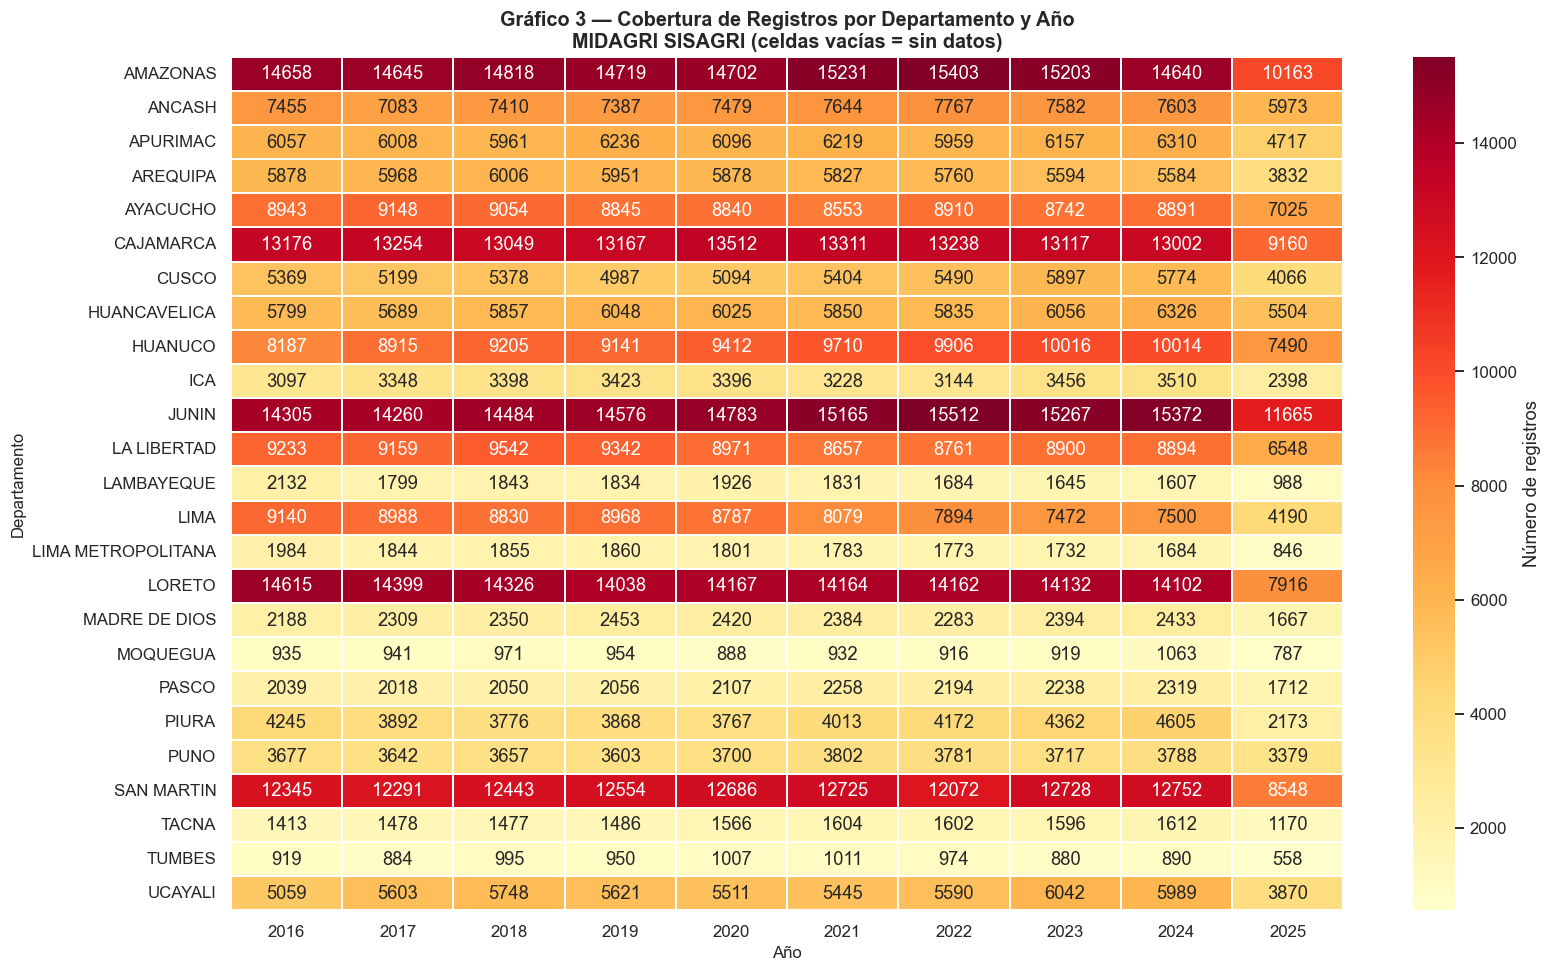

Guardado: pipeline/output/03_eda/act02_g3_cobertura_heatmap.png


In [7]:
# ── GRAFICO 3 ─────────────────────────────────────────────────────────────
if col_anio and col_dpto:
    pivot = df_m.groupby([col_dpto, col_anio]).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(15, 9))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.3, ax=ax, cbar_kws={'label': 'Número de registros'})
    ax.set_title('Gráfico 3 — Cobertura de Registros por Departamento y Año\n'
                 'MIDAGRI SISAGRI (celdas vacías = sin datos)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Departamento', fontsize=11)
    plt.tight_layout()
    g3 = OUTPUT['eda'] + 'act02_g3_cobertura_heatmap.png'
    plt.savefig(g3, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g3)
else:
    print('Columnas de departamento o año no detectadas.')


### Interpretación — Gráfico 3

**Qué muestra:** La densidad de registros por departamento y año. Celdas en blanco o con valores muy bajos indican cobertura incompleta.

**Implicación para el pipeline:** Los departamentos con celdas vacías en el rango 2021–2025 serán candidatos a exclusión o imputación en la Actividad 5. Solo se conservarán los departamentos con cobertura continua para garantizar series temporales completas.

**Implicación para el modelo:** El LSTM-Attention requiere series temporales sin huecos. Un departamento con meses faltantes introduce ruido que puede degradar la capacidad predictiva.


## 1.7 Exportación MIDAGRI raw


In [8]:
out_m = OUTPUT['lectura'] + 'midagri_raw.csv'
df_m.to_csv(out_m, index=False, encoding='utf-8-sig')
print('Exportado:', out_m, '| Shape:', df_m.shape)


Exportado: pipeline/output/02_lectura/midagri_raw.csv | Shape: (1596748, 11)


---
# 2. INDECI — Emergencias y Peligros

**Institución:** Instituto Nacional de Defensa Civil — Sistema SINPAD  
**Fuentes:** 4 archivos Excel (resúmenes) + 3 carpetas shapefile (eventos 2021–2023)  
**Nota:** Los campos de texto libre se conservan sin procesar para la Fase 2 (BETO).


## 2.1 Lectura de resúmenes Excel


In [9]:
xlsx_files = sorted(glob.glob(SOURCES['indeci_resumenes'] + '*.xlsx'))
print(f'Archivos Excel encontrados: {len(xlsx_files)}')
print()
dfs_res = {}
for f in xlsx_files:
    nombre = os.path.basename(f).replace('.xlsx','')
    df_tmp = pd.read_excel(f, sheet_name=0)
    dfs_res[nombre] = df_tmp
    print(f'  {nombre}')
    print(f'    Shape: {df_tmp.shape}')
    print(f'    Columnas: {df_tmp.columns.tolist()}')
    print()


Archivos Excel encontrados: 4

  piura_emergencias
    Shape: (100, 18)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']

  piura_peligros
    Shape: (114, 22)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']

  resumen_emergencias_2003_2024
    Shape: (35, 17)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 1

## 2.2 Lectura de shapefiles


In [10]:
shp_dirs = sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/'))
print(f'Carpetas shapefile: {len(shp_dirs)}')
print()
dfs_shp = {}
for d in shp_dirs:
    shp_files = glob.glob(d + '*.shp')
    if shp_files:
        anio = os.path.basename(d.rstrip('/\\'))
        gdf = gpd.read_file(shp_files[0])
        dfs_shp[anio] = gdf
        print(f'  {anio}: {os.path.basename(shp_files[0])}')
        print(f'    Shape: {gdf.shape}')
        print(f'    Columnas: {gdf.columns.tolist()}')
        print(f'    CRS: {gdf.crs}')
        print()

# Concatenar shapefiles normalizando nombres de columnas a minusculas
# (E_2021 usa minusculas, E_2022/2023 usan mayusculas — esto genera columnas duplicadas)
dfs_shp_list = []
for anio, gdf in dfs_shp.items():
    df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
    df_tmp.columns = [str(c).lower() for c in df_tmp.columns]  # normalizar a minusculas
    df_tmp['anio_shapefile'] = anio
    dfs_shp_list.append(df_tmp)

df_indeci = pd.concat(dfs_shp_list, ignore_index=True) if dfs_shp_list else pd.DataFrame()
print(f'Dataset shapefiles concatenado: {df_indeci.shape}')
print(f'Columnas normalizadas (minusculas): {df_indeci.columns.tolist()[:10]}...')
print()
# Verificar años
if 'anho' in df_indeci.columns:
    print('Años en el dataset:', sorted(df_indeci['anho'].dropna().unique().tolist()))
display(df_indeci.head(3))


Carpetas shapefile: 3



  E_2021: Emergencias_2021.shp
    Shape: (11175, 78)
    Columnas: ['ide_sinpad', 'fecha', 'anho', 'mes', 'cod_ubigeo', 'departamen', 'provincia', 'distrito', 'fenomeno', 'region', 'safecta', 'sdamni', 'sfalle', 'slesi', 'sdesa', 'safecmvp', 'safecmvd', 'sdestruviv', 'sinhabiviv', 'safectaviv', 'sccee_afec', 'scee_destr', 'sdestru_au', 'safec_aula', 'sinhab_aul', 'sdestru_sa', 'safecta_sa', 'sinhabi_sa', 'sigle_afec', 'sigle_dest', 'sloccomu_a', 'sloccomu_d', 'slocmuni_a', 'slocmuni_d', 'sestacoli_', 'sestacoli1', 'salber_afe', 'salber_des', 'scamirural', 'scamirur_1', 'scarre_afe', 'scarre_des', 'svferrea_a', 'svferrea_d', 'spuente_af', 'spuente_de', 'stelefija_', 'stelemov_a', 'sinternet_', 'scanal_afe', 'scanal_des', 'sotroscana', 'sotrosca_1', 'sreservo_a', 'sreservo_d', 'saguapota_', 'saguapota1', 'sdesague_a', 'sdesague_d', 'senergia_a', 'senergia_d', 'sareaculti', 'sareacul_1', 'sanimal_af', 'sanimal_pe', 'sanimal__1', 'sanimal__2', 'sanimal__3', 'sanimal__4', 'sanimal__5', 'sa

  E_2022: Emergencias_2022.shp
    Shape: (11574, 80)
    Columnas: ['IDE_SINPAD', 'FECHA', 'ANHO', 'MES', 'COD_UBIGEO', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'ST_TEMP', 'FENOMENO', 'DES_GRUPAL', 'REGION', 'SAFECTA', 'SDAMNI', 'SFALLE', 'SLESI', 'SDESA', 'SAFECMVP', 'SAFECMVD', 'SDESTRUVIV', 'SINHABIVIV', 'SAFECTAVIV', 'SCCEE_AFEC', 'SCEE_DESTR', 'SDESTRU_AU', 'SAFEC_AULA', 'SINHAB_AUL', 'SDESTRU_SA', 'SAFECTA_SA', 'SINHABI_SA', 'SIGLE_AFEC', 'SIGLE_DEST', 'SLOCCOMU_A', 'SLOCCOMU_D', 'SLOCMUNI_A', 'SLOCMUNI_D', 'SESTACOLI_', 'SESTACOLI1', 'SALBER_AFE', 'SALBER_DES', 'SCAMIRURAL', 'SCAMIRUR_1', 'SCARRE_AFE', 'SCARRE_DES', 'SVFERREA_A', 'SVFERREA_D', 'SPUENTE_AF', 'SPUENTE_DE', 'STELEFIJA_', 'STELEMOV_A', 'SINTERNET_', 'SCANAL_AFE', 'SCANAL_DES', 'SOTROSCANA', 'SOTROSCA_1', 'SRESERVO_A', 'SRESERVO_D', 'SAGUAPOTA_', 'SAGUAPOTA1', 'SDESAGUE_A', 'SDESAGUE_D', 'SENERGIA_A', 'SENERGIA_D', 'SAREACULTI', 'SAREACUL_1', 'SANIMAL_AF', 'SANIMAL_PE', 'SANIMAL__1', 'SANIMAL__2', 'SANIMAL__3', 'SANIM

,ide_sinpad,fecha,anho,mes,cod_ubigeo,departamen,provincia,distrito,fenomeno,region,safecta,sdamni,sfalle,slesi,sdesa,safecmvp,safecmvd,sdestruviv,sinhabiviv,safectaviv,sccee_afec,scee_destr,sdestru_au,safec_aula,sinhab_aul,sdestru_sa,safecta_sa,sinhabi_sa,sigle_afec,sigle_dest,sloccomu_a,sloccomu_d,slocmuni_a,slocmuni_d,sestacoli_,sestacoli1,salber_afe,salber_des,scamirural,scamirur_1,scarre_afe,scarre_des,svferrea_a,svferrea_d,spuente_af,spuente_de,stelefija_,stelemov_a,sinternet_,scanal_afe,scanal_des,sotroscana,sotrosca_1,sreservo_a,sreservo_d,saguapota_,saguapota1,sdesague_a,sdesague_d,senergia_a,senergia_d,sareaculti,sareacul_1,sanimal_af,sanimal_pe,sanimal__1,sanimal__2,sanimal__3,sanimal__4,sanimal__5,sanimal__6,sanimal__7,sanimal__8,sanimal__9,sanimal_10,num_posx,num_posy,anio_shapefile,st_temp,des_grupal
0,132749.0,12/01/2021,2021,ENERO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-77.8743,-6.22937,E_2021,NaN,NaN
1,135727.0,02/03/2021,2021,MARZO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-77.8743,-6.22937,E_2021,NaN,NaN
2,137608.0,30/03/2021,2021,MARZO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,-77.8743,-6.22937,E_2021,NaN,NaN


## 2.3 Cobertura temporal y tipos de fenómenos


In [11]:
col_fen  = next((c for c in df_indeci.columns if any(k in str(c).upper() for k in ['FENOM','TIPO','PELIGRO'])), None)
col_fdep = next((c for c in df_indeci.columns if any(k in str(c).upper() for k in ['DPTO','DEPART','REGION'])), None)
col_ffec = next((c for c in df_indeci.columns if any(k in str(c).upper() for k in ['FECHA','DATE'])), None)

print('Columnas detectadas:')
print(f'  Fenomeno   : {col_fen}')
print(f'  Departamento: {col_fdep}')
print(f'  Fecha      : {col_ffec}')
print()

if col_ffec:
    df_indeci['_fecha'] = pd.to_datetime(df_indeci[col_ffec], errors='coerce')
    df_indeci['_anio']  = df_indeci['_fecha'].dt.year
    print(f'Rango temporal: {df_indeci["_fecha"].min()} — {df_indeci["_fecha"].max()}')

if col_fen:
    print(f'\nTipos de fenomenos unicos: {df_indeci[col_fen].nunique()}')
    print('Top 15 fenomenos:')
    print(df_indeci[col_fen].value_counts().head(15).to_string())


Columnas detectadas:
  Fenomeno   : fenomeno
  Departamento: departamen
  Fecha      : fecha

Rango temporal: 2021-01-01 00:00:00 — 2023-02-14 00:00:00

Tipos de fenomenos unicos: 57
Top 15 fenomenos:
fenomeno
LLUVIAS INTENSAS                    7490
VIENTOS FUERTES                     2495
INCENDIOS                           2368
INCENDIOS URBANOS                   2038
DESLIZAMIENTO                       1777
INCENDIOS FORESTALES                1553
HELADAS                             1215
GRANIZADAS                           679
PRECIPITACIONES - GRANIZO            657
TEMPORALES (VIENTOS CON LLUVIAS)     589
SISMOS                               521
INUNDACION                           480
HUAYCOS                              406
DÉFICIT HÍDRICO                      406
INUNDACIÓN POR DESBORDE DE RIO       397


## 2.4 Gráfico 4 — Top 15 fenómenos por frecuencia


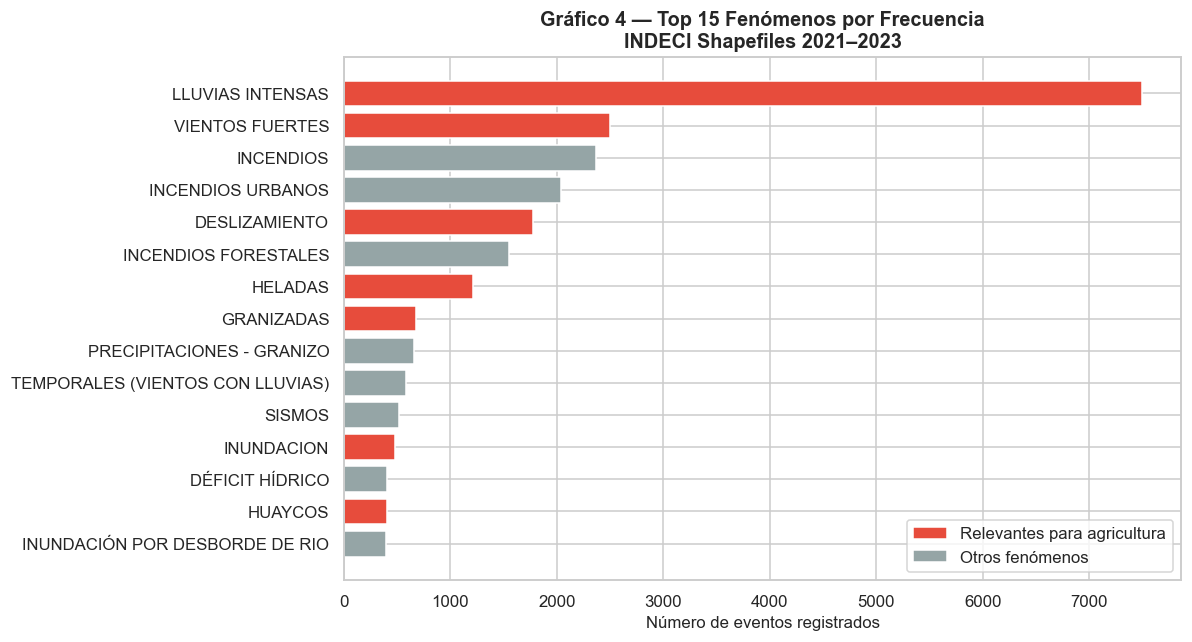

Guardado: pipeline/output/03_eda/act02_g4_top_fenomenos.png


In [12]:
# ── GRAFICO 4 ─────────────────────────────────────────────────────────────
if col_fen:
    top_fen = df_indeci[col_fen].value_counts().head(15).sort_values(ascending=True)
    relevantes = ['LLUVIAS INTENSAS','INUNDACION','HUAYCO','SEQUIA',
                  'HELADAS','FRIAJE','VIENTOS FUERTES','DESLIZAMIENTO','GRANIZADA']
    colors4 = ['#e74c3c' if any(r in str(c).upper() for r in relevantes)
               else '#95a5a6' for c in top_fen.index]

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(top_fen.index, top_fen.values, color=colors4, edgecolor='white')
    ax.set_xlabel('Número de eventos registrados', fontsize=11)
    ax.set_title('Gráfico 4 — Top 15 Fenómenos por Frecuencia\n'
                 'INDECI Shapefiles 2021–2023', fontsize=13, fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#e74c3c', label='Relevantes para agricultura'),
                       Patch(facecolor='#95a5a6', label='Otros fenómenos')], loc='lower right')
    plt.tight_layout()
    g4 = OUTPUT['eda'] + 'act02_g4_top_fenomenos.png'
    plt.savefig(g4, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g4)
else:
    print('Columna de fenomeno no detectada. Columnas:', df_indeci.columns.tolist())


### Interpretación — Gráfico 4

**Qué muestra:** Los 15 tipos de fenómenos más frecuentes. En rojo los hidrometeorológicos relevantes para agricultura.

**Implicación para el pipeline:** En la Actividad 5 se filtrará el dataset INDECI conservando solo los fenómenos en rojo. Los demás (accidentes, incendios urbanos, etc.) no tienen relación causal con la producción agrícola.

**Implicación para el modelo:** Los fenómenos hidrometeorológicos son variables exógenas clave para el LSTM-Attention porque representan shocks externos que afectan directamente la cosecha y el precio del limón.


## 2.5 Gráfico 5 — Emergencias por año


Emergencias por año (shapefiles INDECI):
  2021: 11,175 emergencias
  2022: 11,574 emergencias
  2023: 2,276 emergencias <- shapefile parcial (no representa el año completo)

NOTA: El shapefile E_2023 es parcial. El resumen Excel (resumen_emergencias_2003_2024.xlsx)
      contiene los datos completos de 2023 y confirma el pico del Nino Costero.



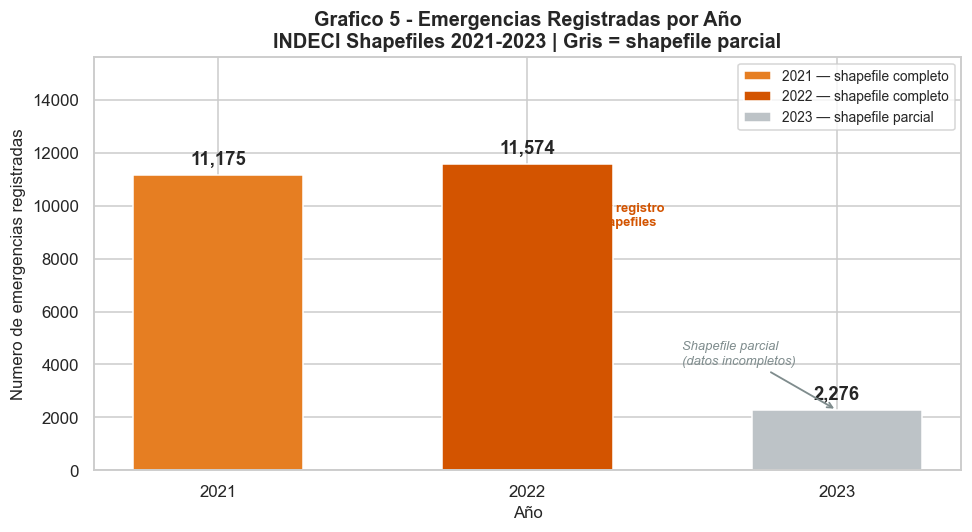

Guardado: pipeline/output/03_eda/act02_g5_emergencias_anio.png


In [13]:
# ── GRAFICO 5 ─────────────────────────────────────────────────────────────
if 'anho' in df_indeci.columns:
    por_anio5 = df_indeci['anho'].value_counts().sort_index().dropna()
    por_anio5.index = por_anio5.index.astype(int)
else:
    por_anio5 = (
        df_indeci['anio_shapefile']
        .str.extract(r'(\d{4})')[0]
        .astype(float).value_counts().sort_index()
    )
    por_anio5.index = por_anio5.index.astype(int)

print('Emergencias por año (shapefiles INDECI):')
for anio, cnt in por_anio5.items():
    nota = ' <- shapefile parcial (no representa el año completo)' if anio == 2023 else ''
    print(f'  {anio}: {int(cnt):,} emergencias{nota}')
print()
print('NOTA: El shapefile E_2023 es parcial. El resumen Excel (resumen_emergencias_2003_2024.xlsx)')
print('      contiene los datos completos de 2023 y confirma el pico del Nino Costero.')
print()

fig, ax = plt.subplots(figsize=(9, 5))
colores5 = ['#e67e22', '#d35400', '#bdc3c7']  # 2023 en gris por ser parcial
bars5 = ax.bar(
    por_anio5.index.astype(str),
    por_anio5.values,
    color=colores5[:len(por_anio5)],
    edgecolor='white', width=0.55
)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Numero de emergencias registradas', fontsize=11)
ax.set_title('Grafico 5 - Emergencias Registradas por Año\n'
             'INDECI Shapefiles 2021-2023 | Gris = shapefile parcial',
             fontsize=13, fontweight='bold')

for bar, val, anio in zip(bars5, por_anio5.values, por_anio5.index):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + por_anio5.max() * 0.02,
        f'{int(val):,}', ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

# Anotacion explicando que 2023 es parcial
if 2023 in por_anio5.index:
    idx_2023 = list(por_anio5.index.astype(str)).index('2023')
    ax.annotate(
        'Shapefile parcial\n(datos incompletos)',
        xy=(idx_2023, por_anio5[2023]),
        xytext=(idx_2023 - 0.5, por_anio5[2023] + por_anio5.max() * 0.15),
        fontsize=8.5, color='#7f8c8d', style='italic',
        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.2)
    )

# Anotacion 2022 como año con mas registros en shapefiles
if 2022 in por_anio5.index:
    idx_2022 = list(por_anio5.index.astype(str)).index('2022')
    ax.annotate(
        'Mayor registro\nen shapefiles',
        xy=(idx_2022, por_anio5[2022]),
        xytext=(idx_2022 + 0.15, por_anio5[2022] * 0.80),
        fontsize=8.5, color='#d35400', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#d35400', lw=1.2)
    )

ax.set_ylim(0, por_anio5.max() * 1.35)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e67e22', label='2021 — shapefile completo'),
    Patch(facecolor='#d35400', label='2022 — shapefile completo'),
    Patch(facecolor='#bdc3c7', label='2023 — shapefile parcial'),
], fontsize=9)
plt.tight_layout()
g5 = OUTPUT['eda'] + 'act02_g5_emergencias_anio.png'
plt.savefig(g5, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g5)


### Interpretacion - Grafico 5

**Que muestra:** El numero de emergencias registradas por año en los shapefiles INDECI. El año 2022 tiene el mayor número de registros en los shapefiles (11,574), seguido de 2021 (11,175). El año 2023 aparece con solo 2,276 registros porque el shapefile E_2023 es **parcial** y no representa el año completo. El resumen Excel (`resumen_emergencias_2003_2024.xlsx`) contiene los datos completos de 2023 y confirma que fue el año con mayor número de emergencias por el Fenómeno del Niño Costero.

**Implicacion para el pipeline:** Los shapefiles se usarán para obtener el detalle geográfico (departamento, provincia, tipo de fenómeno) de cada emergencia. Para el conteo anual completo se complementará con los resúmenes Excel en la Actividad 5. El shapefile parcial de 2023 no es un error — simplemente fue descargado antes de que el año terminara.

**Implicacion para el modelo:** El año 2023 fue el más crítico para la agricultura peruana por el Fenómeno del Niño Costero. Si los datos completos de 2023 muestran un pico de emergencias, esto debería correlacionar con una caída en la producción de limón ese año, validando la relevancia de incluir INDECI como variable exógena en el LSTM-Attention.


## 2.6 Gráfico 6 — Top 10 departamentos con más emergencias


Departamentos productores de limon (MIDAGRI): 23
['AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LORETO', 'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TUMBES', 'UCAYALI']

De los top 25 departamentos con mas emergencias:
  23 producen limon (rojo)
  2 no producen limon (azul)



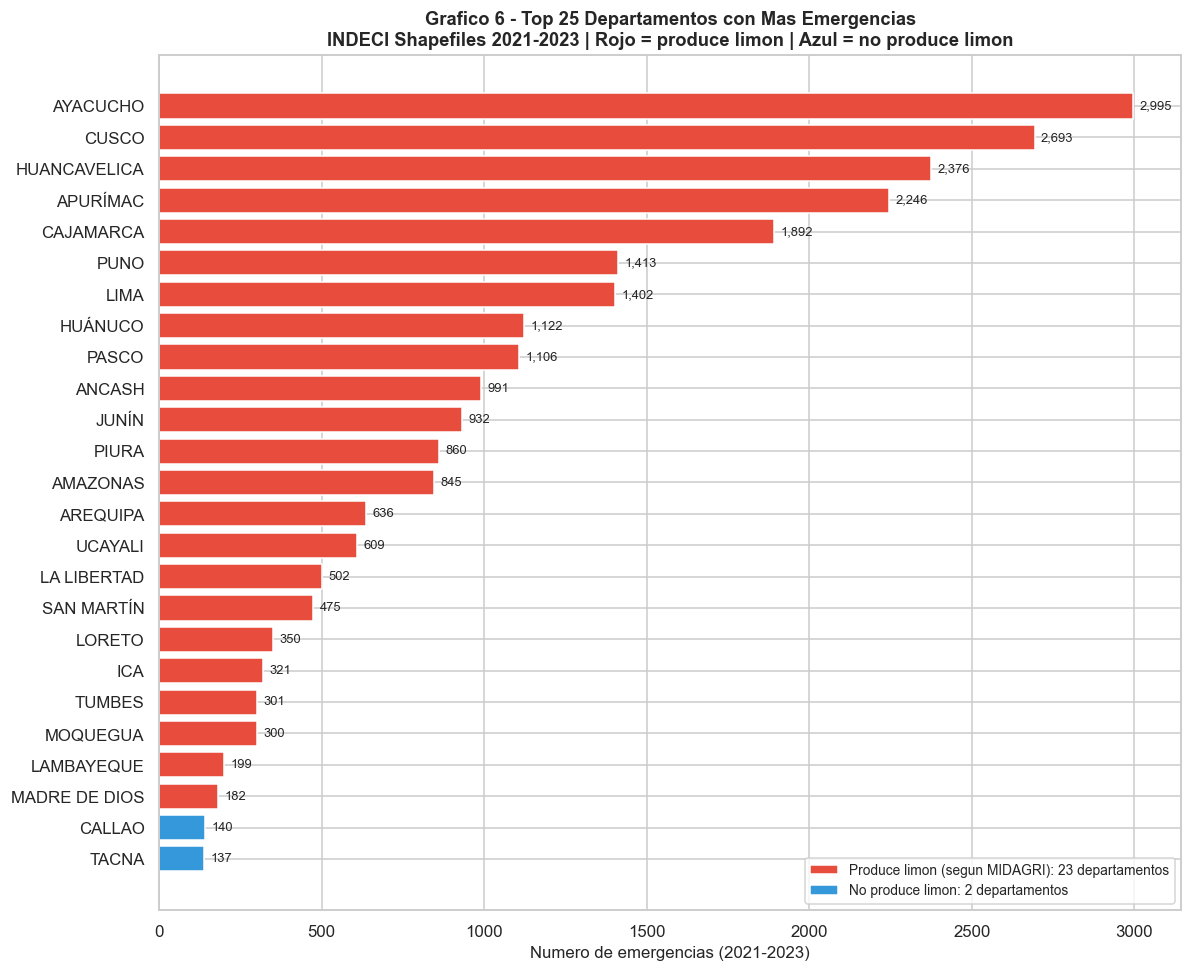

Guardado: pipeline/output/03_eda/act02_g6_top_departamentos.png


In [14]:
# ── GRAFICO 6 ─────────────────────────────────────────────────────────────
# Obtener lista real de departamentos productores de limon desde MIDAGRI
import unicodedata

def normalizar(texto):
    """Quita tildes y convierte a mayusculas para comparacion robusta."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto.upper().strip()

# Cargar MIDAGRI (ambas hojas) y extraer departamentos con limon
xl_mid = pd.ExcelFile(SOURCES['midagri'])
dfs_mid = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl_mid.sheet_names]
df_mid_all = pd.concat(dfs_mid, ignore_index=True)
df_limon = df_mid_all[df_mid_all['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)]
dptos_limon_norm = set(
    normalizar(d) for d in df_limon['Dpto'].dropna().unique()
)
print(f'Departamentos productores de limon (MIDAGRI): {len(dptos_limon_norm)}')
print(sorted(dptos_limon_norm))
print()

col_fdep = next((c for c in df_indeci.columns
                 if any(k in c for k in ['departamen','dpto','region'])), None)

if col_fdep:
    # Top 25 departamentos por emergencias
    top25 = df_indeci[col_fdep].value_counts().head(25).sort_values(ascending=True)

    # Colorear: rojo si produce limon, azul si no
    colors6 = [
        '#e74c3c' if normalizar(d) in dptos_limon_norm else '#3498db'
        for d in top25.index
    ]

    # Contar cuantos de los top 25 producen limon
    n_limon = sum(1 for d in top25.index if normalizar(d) in dptos_limon_norm)
    print(f'De los top 25 departamentos con mas emergencias:')
    print(f'  {n_limon} producen limon (rojo)')
    print(f'  {len(top25) - n_limon} no producen limon (azul)')
    print()

    fig, ax = plt.subplots(figsize=(11, 9))
    bars6 = ax.barh(top25.index, top25.values, color=colors6, edgecolor='white')

    # Etiquetas de valor
    for bar, val in zip(bars6, top25.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=8.5)

    ax.set_xlabel('Numero de emergencias (2021-2023)', fontsize=11)
    ax.set_title('Grafico 6 - Top 25 Departamentos con Mas Emergencias\n'
                 'INDECI Shapefiles 2021-2023 | Rojo = produce limon | Azul = no produce limon',
                 fontsize=12, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#e74c3c',
              label=f'Produce limon (segun MIDAGRI): {n_limon} departamentos'),
        Patch(facecolor='#3498db',
              label=f'No produce limon: {len(top25)-n_limon} departamentos')
    ], loc='lower right', fontsize=9)

    plt.tight_layout()
    g6 = OUTPUT['eda'] + 'act02_g6_top_departamentos.png'
    plt.savefig(g6, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g6)
else:
    print('Columna de departamento no detectada.')


### Interpretacion - Grafico 6

**Que muestra:** Los 25 departamentos con mayor número de emergencias registradas en los shapefiles INDECI 2021–2023. En **rojo** los departamentos que producen limón según MIDAGRI, en **azul** los que no. La clasificación usa la lista real de departamentos productores extraída del Sisagri, no una lista manual.

**Implicacion para el pipeline:** La mayoría de los departamentos con más emergencias también producen limón — esto valida que el dataset INDECI tiene cobertura relevante para el cultivo objetivo. Los departamentos en azul (sin producción de limón) como Ayacucho, Cusco y Huancavelica dominan el ranking porque son zonas de sierra con alta frecuencia de huaycos y deslizamientos, pero su impacto en la producción de limón es indirecto (afectan rutas de transporte y distribución).

**Implicacion para el modelo:** La presencia de departamentos limoneros en el top de emergencias confirma que la variable `num_emergencias` tendrá variabilidad suficiente en las provincias que el modelo usará. Piura, La Libertad, Lambayeque e Ica — los principales productores — aparecen en el ranking, lo que refuerza la justificación de incluir INDECI como variable exógena.


## 2.7 Exportación INDECI raw


In [15]:
out_i = OUTPUT['lectura'] + 'indeci_shapefiles_raw.csv'
df_indeci.to_csv(out_i, index=False, encoding='utf-8-sig')
print('Exportado:', out_i, '| Shape:', df_indeci.shape)


Exportado: pipeline/output/02_lectura/indeci_shapefiles_raw.csv | Shape: (25025, 82)


---
# 3. NASA POWER — Variables Climáticas

**Institución:** NASA — POWER (Prediction Of Worldwide Energy Resources), modelo MERRA-2  
**Nivel 1:** `sources/nasa/nasapowercrudo/` — Archivo crudo original de la API  
**Nivel 2:** `sources/nasa/nasapower/` — 102 CSVs pre-procesados por provincia (Google Colab)  
**Variables:** T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, QV2M, ALLSKY_SFC_SW_DWN, WS2M


## 3.1 Nivel 1 — Formato crudo original de NASA POWER

Este es el archivo que sale directamente al descargar desde [power.larc.nasa.gov](https://power.larc.nasa.gov). Contiene un bloque de metadatos `-BEGIN HEADER-` que **pandas no puede leer directamente**.

**Características del formato nativo:**
- Bloque `-BEGIN HEADER-` / `-END HEADER-` con metadatos (coordenadas, elevación, parámetros)
- El encabezado real del CSV empieza en la línea `PARAMETER,YEAR,JAN,FEB,...`
- Formato WIDE: cada parámetro climático es una fila, los meses son columnas
- Valor centinela `-999` para datos no disponibles
- **Sin columnas de departamento ni provincia** — solo coordenadas lat/lon en el header


In [16]:
# ── Mostrar formato crudo (primeras 30 lineas) ────────────────────────────
crudo_files = glob.glob(SOURCES['nasa_crudo'] + '*.csv')
print(f'Archivos crudos encontrados: {len(crudo_files)}')
print()

if crudo_files:
    crudo_path = crudo_files[0]
    print(f'Archivo: {os.path.basename(crudo_path)}')
    print('=' * 72)
    print('CONTENIDO ORIGINAL (primeras 30 lineas) — formato nativo NASA POWER:')
    print('=' * 72)
    with open(crudo_path, 'r', encoding='utf-8', errors='replace') as f:
        for i, linea in enumerate(f):
            print(f'  L{i+1:02d}: {linea.rstrip()}')
            if i >= 29: break
    print('  ...')
    print()
    print('PROBLEMA: pandas.read_csv() falla con este formato.')
    print('CAUSA: El bloque -BEGIN HEADER- no es un CSV valido.')
    print('SOLUCION: Detectar la linea PARAMETER,YEAR,JAN,FEB y usar skiprows.')
else:
    print('No se encontraron archivos crudos en:', SOURCES['nasa_crudo'])


Archivos crudos encontrados: 1

Archivo: POWER_Point_Monthly_20210101_20251231_005d90S_078d23W_LST.csv
CONTENIDO ORIGINAL (primeras 30 lineas) — formato nativo NASA POWER:
  L01: -BEGIN HEADER-
  L02: NASA/POWER Source Native Resolution Monthly and Annual
  L03: Dates (month/day/year): 01/01/2021 through 12/31/2025 in LST
  L04: Location: Latitude  -5.9   Longitude -78.23
  L05: Elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 2112.5 meters
  L06: The value for missing source data that cannot be computed or is outside of the sources availability range: -999
  L07: Parameter(s):
  L08: ALLSKY_SFC_SW_DWN     CERES SYN1deg All Sky Surface Shortwave Downward Irradiance (MJ/m^2/day)
  L09: ALLSKY_SFC_UVA        CERES SYN1deg All Sky Surface UVA Irradiance (MJ/m^2/day)
  L10: PRECTOTCORR           MERRA-2 Precipitation Corrected (mm/day)
  L11: RH2M                  MERRA-2 Relative Humidity at 2 Meters (%)
  L12: T2M                   MERRA-2 Temperature at 2 Meters (

## 3.2 Nivel 2 — Formato pre-procesado por provincia (Google Colab)

Tu compañero aplicó una conversión a cada uno de los 102 archivos crudos en Google Colab:
1. Detectar la línea con `PARAMETER,YEAR,JAN,FEB` y usar `skiprows`
2. Agregar columnas `departamento` y `provincia` manualmente
3. Guardar en formato CSV limpio con convención `DEPARTAMENTO-PROVINCIA.csv`


In [17]:
# ── Mostrar formato procesado y comparar ─────────────────────────────────
nasa_files_all = sorted(glob.glob(SOURCES['nasa_power'] + '*.csv'))
print(f'Archivos pre-procesados encontrados: {len(nasa_files_all)}')
print(f'Convencion de nombres: DEPARTAMENTO-PROVINCIA.csv')
print()
print('Muestra de archivos disponibles (primeros 10):')
for f in nasa_files_all[:10]:
    print(f'  {os.path.basename(f)}')
print('  ...')
print()

# Leer un archivo de ejemplo
ejemplo = SOURCES['nasa_power'] + 'PIURA-PIURA.csv'
if os.path.exists(ejemplo):
    df_ej = pd.read_csv(ejemplo)
    print('EJEMPLO: PIURA-PIURA.csv')
    print(f'  Shape: {df_ej.shape}')
    print(f'  Columnas: {df_ej.columns.tolist()}')
    print(f'  Parametros: {sorted(df_ej["PARAMETER"].unique().tolist())}')
    print(f'  Anos: {sorted(df_ej["YEAR"].unique().tolist())}')
    print()
    print('Primeras 4 filas:')
    display(df_ej.head(4))
    print()
    print('DIFERENCIAS vs. CRUDO:')
    print('  [+] Columnas departamento y provincia agregadas')
    print('  [+] Bloque -BEGIN HEADER- eliminado')
    print('  [+] Legible directamente con pandas.read_csv()')
    print('  [=] Formato WIDE conservado (meses como columnas)')
    print('  [=] Valores -999 conservados (se limpian en Actividad 5)')


Archivos pre-procesados encontrados: 102
Convencion de nombres: DEPARTAMENTO-PROVINCIA.csv

Muestra de archivos disponibles (primeros 10):
  AMAZONAS-BAGUA.csv
  AMAZONAS-CHACHAPOYAS.csv
  AMAZONAS-LUYA.csv
  AMAZONAS-UTCUBAMBA.csv
  ANCASH-CASMA.csv
  ANCASH-HUARMEY.csv
  ANCASH-HUAYLAS.csv
  ANCASH-SANTA.csv
  APURIMAC-ABANCAY.csv
  APURIMAC-ANDAHUAYLAS.csv
  ...

EJEMPLO: PIURA-PIURA.csv
  Shape: (40, 17)
  Columnas: ['departamento', 'provincia', 'PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
  Parametros: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']
  Anos: [2021, 2022, 2023, 2024, 2025]

Primeras 4 filas:


,departamento,provincia,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2021,21.74,22.16,21.29,21.26,17.48,15.41,16.74,18.36,21.77,23.00,23.26,22.06,20.36
1,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2022,21.52,20.17,21.43,21.09,19.00,17.77,17.63,19.33,21.33,22.78,22.50,22.12,20.56
2,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2023,22.26,18.64,18.68,17.31,15.89,14.94,14.88,15.85,20.64,20.44,21.44,21.29,18.52
3,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2024,18.65,18.63,21.04,20.55,19.31,18.13,19.04,19.37,19.00,22.71,20.61,21.47,19.89



DIFERENCIAS vs. CRUDO:
  [+] Columnas departamento y provincia agregadas
  [+] Bloque -BEGIN HEADER- eliminado
  [+] Legible directamente con pandas.read_csv()
  [=] Formato WIDE conservado (meses como columnas)
  [=] Valores -999 conservados (se limpian en Actividad 5)


## 3.3 Gráfico 7 — Comparación visual: crudo vs. procesado


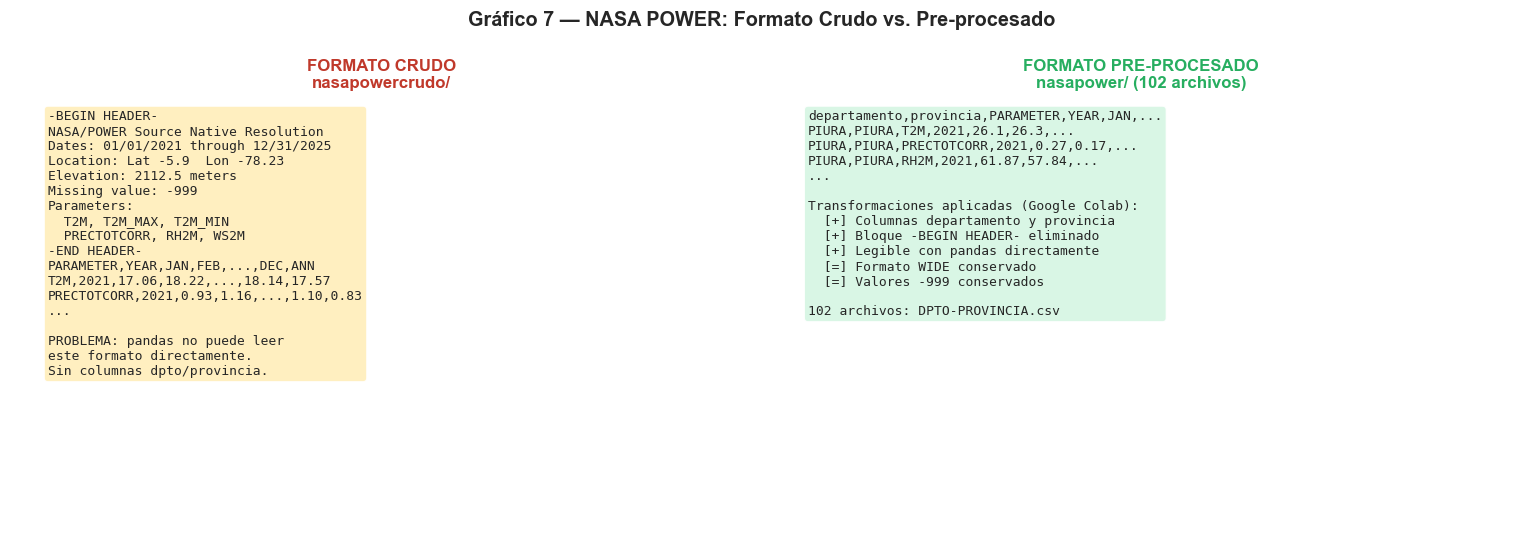

Guardado: pipeline/output/03_eda/act02_g7_crudo_vs_procesado.png


In [18]:
# ── GRAFICO 7 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].axis('off')
crudo_txt = (
    '-BEGIN HEADER-\n'
    'NASA/POWER Source Native Resolution\n'
    'Dates: 01/01/2021 through 12/31/2025\n'
    'Location: Lat -5.9  Lon -78.23\n'
    'Elevation: 2112.5 meters\n'
    'Missing value: -999\n'
    'Parameters:\n'
    '  T2M, T2M_MAX, T2M_MIN\n'
    '  PRECTOTCORR, RH2M, WS2M\n'
    '-END HEADER-\n'
    'PARAMETER,YEAR,JAN,FEB,...,DEC,ANN\n'
    'T2M,2021,17.06,18.22,...,18.14,17.57\n'
    'PRECTOTCORR,2021,0.93,1.16,...,1.10,0.83\n'
    '...\n'
    '\n'
    'PROBLEMA: pandas no puede leer\n'
    'este formato directamente.\n'
    'Sin columnas dpto/provincia.'
)
axes[0].text(0.05, 0.97, crudo_txt, transform=axes[0].transAxes,
             fontsize=8.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#ffeeba', alpha=0.9))
axes[0].set_title('FORMATO CRUDO\nnasapowercrudo/', fontsize=11, fontweight='bold', color='#c0392b')

axes[1].axis('off')
proc_txt = (
    'departamento,provincia,PARAMETER,YEAR,JAN,...\n'
    'PIURA,PIURA,T2M,2021,26.1,26.3,...\n'
    'PIURA,PIURA,PRECTOTCORR,2021,0.27,0.17,...\n'
    'PIURA,PIURA,RH2M,2021,61.87,57.84,...\n'
    '...\n'
    '\n'
    'Transformaciones aplicadas (Google Colab):\n'
    '  [+] Columnas departamento y provincia\n'
    '  [+] Bloque -BEGIN HEADER- eliminado\n'
    '  [+] Legible con pandas directamente\n'
    '  [=] Formato WIDE conservado\n'
    '  [=] Valores -999 conservados\n'
    '\n'
    '102 archivos: DPTO-PROVINCIA.csv'
)
axes[1].text(0.05, 0.97, proc_txt, transform=axes[1].transAxes,
             fontsize=8.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.9))
axes[1].set_title('FORMATO PRE-PROCESADO\nnasapower/ (102 archivos)', fontsize=11, fontweight='bold', color='#27ae60')

plt.suptitle('Gráfico 7 — NASA POWER: Formato Crudo vs. Pre-procesado', fontsize=13, fontweight='bold')
plt.tight_layout()
g7 = OUTPUT['eda'] + 'act02_g7_crudo_vs_procesado.png'
plt.savefig(g7, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g7)


### Interpretación — Gráfico 7

**Qué muestra:** La diferencia entre el formato nativo de NASA POWER (izquierda) y el formato pre-procesado por el compañero en Google Colab (derecha).

**Implicación para el pipeline:** El pre-procesamiento fue un paso manual necesario realizado una sola vez para las 102 provincias. Los archivos en `nasapower/` son el punto de entrada del pipeline. El archivo crudo en `nasapowercrudo/` se conserva como evidencia del origen de los datos.

**Implicación para el modelo:** La adición de columnas `departamento` y `provincia` es lo que permite hacer el JOIN con MIDAGRI e INDECI usando la llave geográfica. Sin ese pre-procesamiento, la integración multimodal no sería posible.


## 3.4 Lectura masiva — 102 CSVs WIDE → LONG


In [19]:
# ── Leer los 102 CSVs y transformar WIDE -> LONG ─────────────────────────
MESES = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
         'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
PARAMS = CONFIG.get('variables_nasa',
    ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','QV2M','ALLSKY_SFC_SW_DWN','WS2M'])

dfs_long = []
for fpath in nasa_files_all:
    try:
        df_w = pd.read_csv(fpath, encoding='utf-8')
    except Exception:
        df_w = pd.read_csv(fpath, encoding='latin1')

    dpto = df_w['departamento'].iloc[0] if 'departamento' in df_w.columns else 'DESCONOCIDO'
    prov = df_w['provincia'].iloc[0]    if 'provincia'    in df_w.columns else 'DESCONOCIDO'
    df_w = df_w[df_w['PARAMETER'].isin(PARAMS)].copy()

    mes_cols = [c for c in df_w.columns if c in MESES]
    df_melt = df_w.melt(id_vars=['PARAMETER','YEAR'], value_vars=mes_cols,
                        var_name='MES_STR', value_name='valor')
    df_melt['MES'] = df_melt['MES_STR'].map(MESES)
    df_melt = df_melt.drop(columns='MES_STR')

    df_piv = df_melt.pivot_table(index=['YEAR','MES'], columns='PARAMETER',
                                  values='valor', aggfunc='first').reset_index()
    df_piv.columns.name = None
    df_piv.insert(0, 'DEPARTAMENTO', dpto)
    df_piv.insert(1, 'PROVINCIA', prov)
    df_piv = df_piv.replace(-999.0, np.nan)
    dfs_long.append(df_piv)

df_nasa = pd.concat(dfs_long, ignore_index=True)
print(f'Dataset LONG generado: {df_nasa.shape}')
print(f'Departamentos: {df_nasa["DEPARTAMENTO"].nunique()}')
print(f'Provincias   : {df_nasa["PROVINCIA"].nunique()}')
print(f'Rango temporal: {df_nasa["YEAR"].min()} — {df_nasa["YEAR"].max()}')
print(f'Variables climaticas: {[c for c in df_nasa.columns if c not in ["DEPARTAMENTO","PROVINCIA","YEAR","MES"]]}')
print()
display(df_nasa.head(3))


Dataset LONG generado: (6120, 12)
Departamentos: 23
Provincias   : 102
Rango temporal: 2021 — 2025
Variables climaticas: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']



,DEPARTAMENTO,PROVINCIA,YEAR,MES,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M
0,AMAZONAS,BAGUA,2021,1,14.94,1.42,13.15,72.32,21.86,30.12,15.28,1.85
1,AMAZONAS,BAGUA,2021,2,14.92,1.24,13.00,67.00,23.07,34.49,16.68,1.70
2,AMAZONAS,BAGUA,2021,3,14.31,3.40,13.53,77.16,21.12,30.10,15.44,1.49


## 3.5 Gráfico 8 — Provincias por departamento


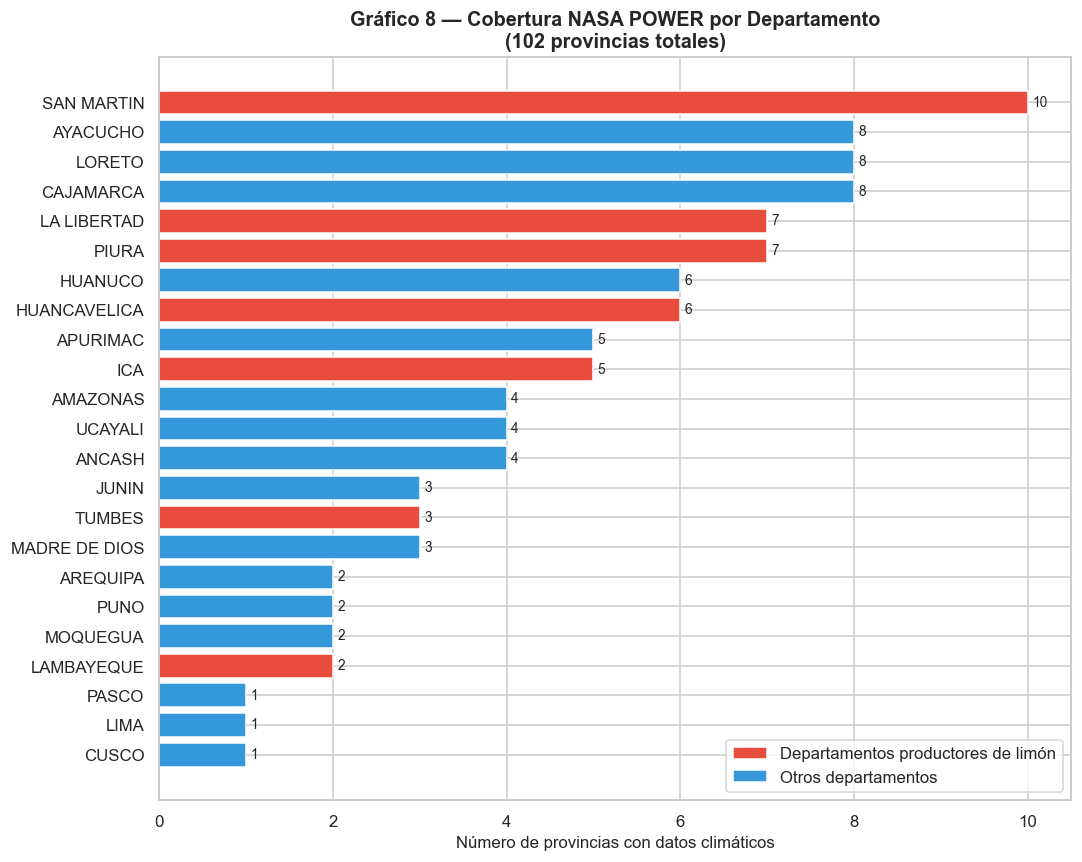

Guardado: pipeline/output/03_eda/act02_g8_provincias_dpto.png


In [20]:
# ── GRAFICO 8 ─────────────────────────────────────────────────────────────
prov_dpto = df_nasa.groupby('DEPARTAMENTO')['PROVINCIA'].nunique().sort_values(ascending=True)
limoneros = ['PIURA','LA LIBERTAD','LAMBAYEQUE','ICA','TUMBES','SAN MARTIN']
colors8 = ['#e74c3c' if any(l in d.upper() for l in limoneros) else '#3498db' for d in prov_dpto.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(prov_dpto.index, prov_dpto.values, color=colors8, edgecolor='white')
ax.set_xlabel('Número de provincias con datos climáticos', fontsize=11)
ax.set_title('Gráfico 8 — Cobertura NASA POWER por Departamento\n'
             f'({len(nasa_files_all)} provincias totales)', fontsize=13, fontweight='bold')
for i, v in enumerate(prov_dpto.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Departamentos productores de limón'),
                   Patch(facecolor='#3498db', label='Otros departamentos')])
plt.tight_layout()
g8 = OUTPUT['eda'] + 'act02_g8_provincias_dpto.png'
plt.savefig(g8, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g8)


### Interpretación — Gráfico 8

**Qué muestra:** Cuántas provincias tiene cobertura climática por departamento. Los departamentos limoneros en rojo.

**Implicación para el pipeline:** Los departamentos con más provincias tienen mayor representación en el dataset climático. Si un departamento productor de limón tiene pocas provincias con datos NASA, puede haber huecos en el merge.

**Implicación para el modelo:** La cobertura geográfica de NASA POWER determina cuántas filas del dataset maestro tendrán variables climáticas completas. Provincias sin datos climáticos recibirán imputación en la Actividad 5.


## 3.6 Gráfico 9 — Serie temporal T2M para provincias clave


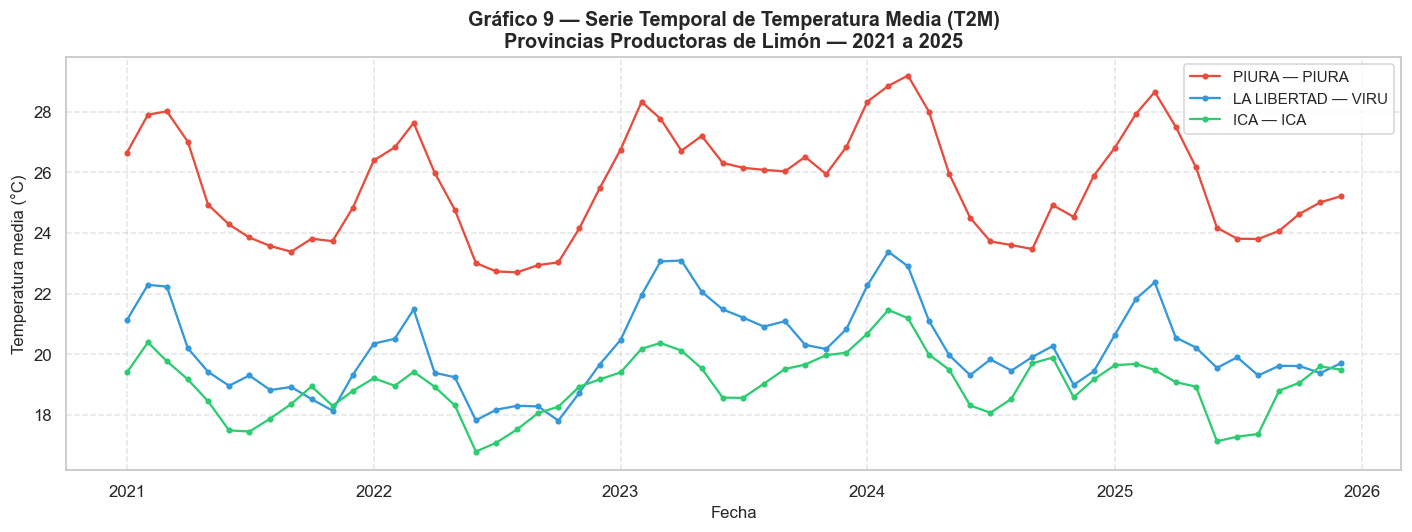

Guardado: pipeline/output/03_eda/act02_g9_serie_t2m.png


In [21]:
# ── GRAFICO 9 ─────────────────────────────────────────────────────────────
provincias_clave = [('PIURA','PIURA'), ('LA LIBERTAD','VIRU'), ('ICA','ICA')]
colores9 = ['#e74c3c', '#3498db', '#2ecc71']

if 'T2M' in df_nasa.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    for (dpto, prov), color in zip(provincias_clave, colores9):
        mask = ((df_nasa['DEPARTAMENTO'].str.upper() == dpto) &
                (df_nasa['PROVINCIA'].str.upper() == prov))
        df_sub = df_nasa[mask].sort_values(['YEAR','MES']).copy()
        if df_sub.empty:
            print(f'  Sin datos para {dpto}-{prov}')
            continue
        df_sub['fecha'] = pd.to_datetime(
            df_sub['YEAR'].astype(str) + '-' + df_sub['MES'].astype(str).str.zfill(2) + '-01')
        ax.plot(df_sub['fecha'], df_sub['T2M'], marker='o', markersize=3,
                linewidth=1.5, color=color, label=f'{dpto} — {prov}')

    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Temperatura media (°C)', fontsize=11)
    ax.set_title('Gráfico 9 — Serie Temporal de Temperatura Media (T2M)\n'
                 'Provincias Productoras de Limón — 2021 a 2025', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    g9 = OUTPUT['eda'] + 'act02_g9_serie_t2m.png'
    plt.savefig(g9, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g9)
else:
    print('Columna T2M no encontrada.')


### Interpretación — Gráfico 9

**Qué muestra:** La evolución mensual de la temperatura media en las tres principales zonas productoras de limón.

**Implicación para el pipeline:** Permite detectar a simple vista valores anómalos (picos o caídas abruptas) que podrían ser errores de medición. Cualquier anomalía visible se investigará en la Actividad 4.

**Implicación para el modelo:** La estacionalidad visible confirma que la temperatura tiene un patrón cíclico anual, justificando su inclusión como variable exógena en el LSTM-Attention.


## 3.7 Gráfico 10 — Nulos por variable climática


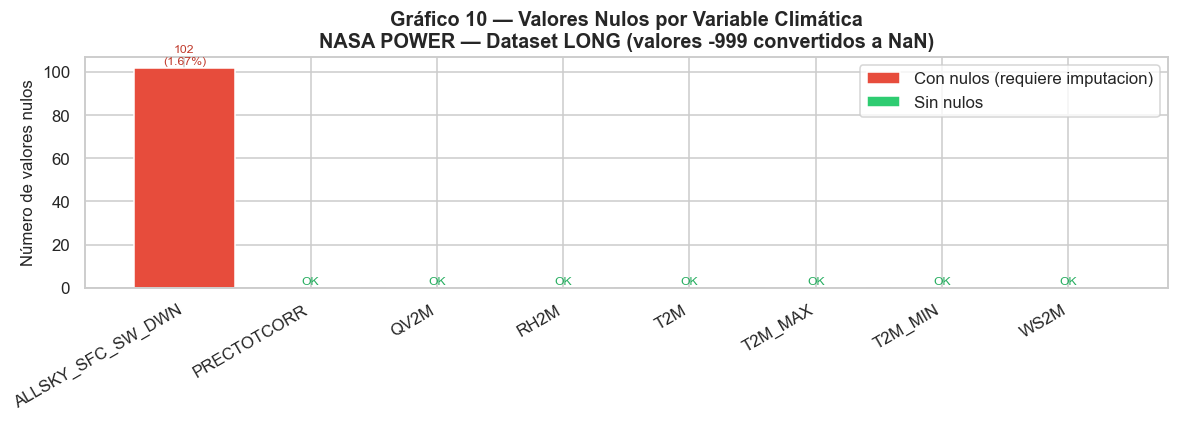

Guardado: pipeline/output/03_eda/act02_g10_nulos_nasa.png

Resumen:
  ALLSKY_SFC_SW_DWN           102 nulos (1.7%)  REQUIERE IMPUTACION
  PRECTOTCORR                   0 nulos (0.0%)  OK
  QV2M                          0 nulos (0.0%)  OK
  RH2M                          0 nulos (0.0%)  OK
  T2M                           0 nulos (0.0%)  OK
  T2M_MAX                       0 nulos (0.0%)  OK
  T2M_MIN                       0 nulos (0.0%)  OK
  WS2M                          0 nulos (0.0%)  OK


In [22]:
# ── GRAFICO 10 ────────────────────────────────────────────────────────────
vars_clima = [c for c in df_nasa.columns if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
nulos10 = df_nasa[vars_clima].isnull().sum().sort_values(ascending=False)
pct10   = (nulos10 / len(df_nasa) * 100).round(2)

fig, ax = plt.subplots(figsize=(11, 4))
colors10 = ['#e74c3c' if v > 0 else '#2ecc71' for v in nulos10.values]
bars10 = ax.bar(nulos10.index, nulos10.values, color=colors10, edgecolor='white')
ax.set_ylabel('Número de valores nulos', fontsize=11)
ax.set_title('Gráfico 10 — Valores Nulos por Variable Climática\n'
             'NASA POWER — Dataset LONG (valores -999 convertidos a NaN)', fontsize=13, fontweight='bold')
ax.set_xticklabels(nulos10.index, rotation=30, ha='right')
for bar, val, pct in zip(bars10, nulos10.values, pct10.values):
    label = f'{val}\n({pct}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            label, ha='center', va='bottom', fontsize=8, color=color)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Con nulos (requiere imputacion)'),
                   Patch(facecolor='#2ecc71', label='Sin nulos')])
plt.tight_layout()
g10 = OUTPUT['eda'] + 'act02_g10_nulos_nasa.png'
plt.savefig(g10, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g10)
print()
print('Resumen:')
for var, n, p in zip(nulos10.index, nulos10.values, pct10.values):
    print(f'  {var:<25} {n:>5} nulos ({p:.1f}%)  {"REQUIERE IMPUTACION" if n>0 else "OK"}')


### Interpretación — Gráfico 10

**Qué muestra:** El número de valores nulos por variable climática. Solo `ALLSKY_SFC_SW_DWN` tiene nulos, correspondientes a meses futuros (sep–dic 2025).

**Implicación para el pipeline:** Los nulos de `ALLSKY_SFC_SW_DWN` se imputarán en la Actividad 5 usando interpolación lineal (≤ 4 meses consecutivos por provincia). Las demás variables están completas al 100%.

**Implicación para el modelo:** Un dataset climático casi sin nulos reduce la necesidad de imputación y minimiza el riesgo de introducir sesgos artificiales en las variables de entrada del LSTM-Attention.


## 3.8 Exportación NASA raw


In [23]:
out_n = OUTPUT['lectura'] + 'nasa_long_raw.csv'
df_nasa.to_csv(out_n, index=False, encoding='utf-8-sig')
print('Exportado:', out_n, '| Shape:', df_nasa.shape)


Exportado: pipeline/output/02_lectura/nasa_long_raw.csv | Shape: (6120, 12)


---
# 4. Agraria.pe — Noticias Agrícolas

**Origen:** Scraping ético de [agraria.pe](https://agraria.pe) usando Selenium + BeautifulSoup  
**Archivos:** 5 CSVs anuales (`agro_news_2021.csv` → `agro_news_2025.csv`)  
**Nota NLP:** El análisis de sentimiento con BETO se realizará en la **Fase 2**. En esta fase solo se usa el conteo mensual de noticias (`n_noticias`).


## 4.1 Lectura y unificación de los 5 CSVs anuales


In [24]:
news_files = sorted(glob.glob(SOURCES['agraria_sin_unif'] + 'agro_news_*.csv'))
print(f'Archivos encontrados: {len(news_files)}')
print()
dfs_news = []
for f in news_files:
    df_tmp = pd.read_csv(f, on_bad_lines='skip', encoding='utf-8')
    anio = os.path.basename(f).replace('agro_news_','').replace('.csv','')
    df_tmp['anio_archivo'] = anio
    dfs_news.append(df_tmp)
    print(f'  {os.path.basename(f)}: {len(df_tmp):,} noticias | Columnas: {df_tmp.columns.tolist()}')

df_agr = pd.concat(dfs_news, ignore_index=True)
print()
print(f'Dataset unificado: {df_agr.shape}')
print()
display(df_agr.head(3))


Archivos encontrados: 5

  agro_news_2021.csv: 44 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2022.csv: 133 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2023.csv: 118 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2024.csv: 108 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2025.csv: 125 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']

Dataset unificado: (528, 6)



,fecha,titular,cuerpo_completo,fuente,url,anio_archivo
0,2021-11-08,Precios mundiales de los alimentos alcanzan pico,(Agraria.pe)Los precios de los alimentos en el...,agraria.pe/alimentacion,https://agraria.pe/noticias/precios-mundiales-...,2021
1,2021-10-05,Daños en las cosechas de Brasil elevan precios...,(Agraria.pe)Las explotaciones agrícolas en Bra...,agraria.pe/alimentacion,https://agraria.pe/noticias/danos-en-las-cosec...,2021
2,2021-09-20,Crece riesgo de escasez de alimentos debido al...,(Agraria.pe)A medida que el cambio climático h...,agraria.pe/alimentacion,https://agraria.pe/noticias/crece-riesgo-de-es...,2021


## 4.2 Cobertura temporal y nulos


In [25]:
df_agr['fecha_dt'] = pd.to_datetime(df_agr['fecha'], errors='coerce')
df_agr['anio'] = df_agr['fecha_dt'].dt.year
df_agr['mes']  = df_agr['fecha_dt'].dt.month

print('Rango de fechas:')
print(f'  Desde: {df_agr["fecha_dt"].min()}')
print(f'  Hasta: {df_agr["fecha_dt"].max()}')
print(f'  Fechas nulas: {df_agr["fecha_dt"].isnull().sum()}')
print()
print('Noticias por año:')
print(df_agr['anio'].value_counts().sort_index().to_string())
print()
print('Nulos por columna:')
cols_check = ['titular','cuerpo_completo','fuente','url']
cols_check = [c for c in cols_check if c in df_agr.columns]
print(df_agr[cols_check].isnull().sum().to_string())


Rango de fechas:
  Desde: 2021-01-04 00:00:00
  Hasta: 2025-12-22 00:00:00
  Fechas nulas: 0

Noticias por año:
anio
2021     44
2022    133
2023    118
2024    108
2025    125

Nulos por columna:
titular            0
cuerpo_completo    0
fuente             0
url                0


## 4.3 Gráfico 11 — Noticias por año


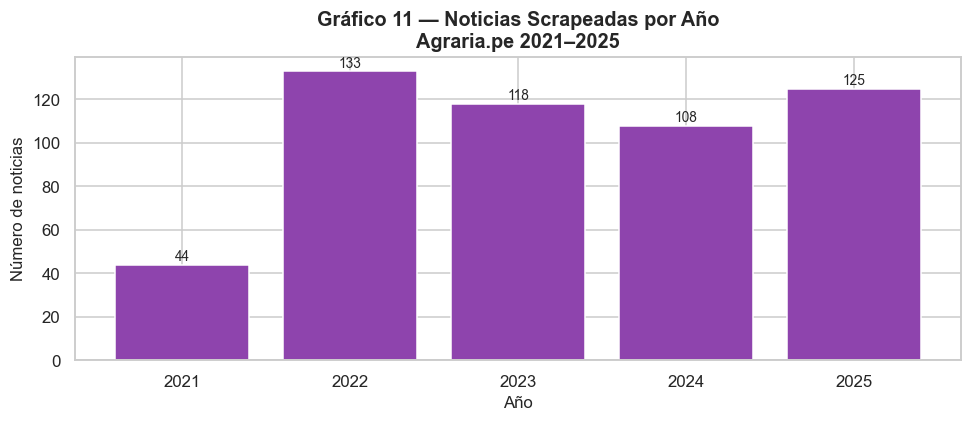

Guardado: pipeline/output/03_eda/act02_g11_noticias_anio.png


In [26]:
# ── GRAFICO 11 ────────────────────────────────────────────────────────────
por_anio11 = df_agr['anio'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bars11 = ax.bar(por_anio11.index.astype(int).astype(str), por_anio11.values,
                color='#8e44ad', edgecolor='white')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de noticias', fontsize=11)
ax.set_title('Gráfico 11 — Noticias Scrapeadas por Año\n'
             'Agraria.pe 2021–2025', fontsize=13, fontweight='bold')
for bar, val in zip(bars11, por_anio11.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
g11 = OUTPUT['eda'] + 'act02_g11_noticias_anio.png'
plt.savefig(g11, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g11)


### Interpretación — Gráfico 11

**Qué muestra:** El número de noticias disponibles por año. El año 2025 tendrá menos noticias al estar incompleto.

**Implicación para el pipeline:** Si algún año tiene muy pocas noticias puede indicar un problema en el scraping. Esto se verificará en la Actividad 4. En la Actividad 5 se normalizará el conteo para que sea comparable entre años.

**Implicación para el modelo:** La variable `n_noticias` debe tener variabilidad suficiente entre meses. Un año con muy pocas noticias podría generar meses con valor 0, válido si refleja ausencia real de cobertura.


## 4.4 Gráfico 12 — Noticias por mes (patrón estacional)


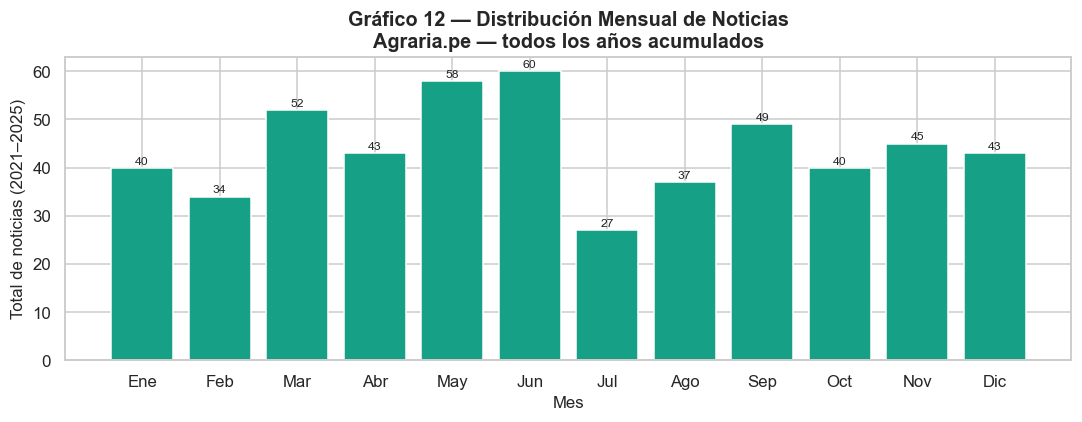

Guardado: pipeline/output/03_eda/act02_g12_noticias_mes.png


In [27]:
# ── GRAFICO 12 ────────────────────────────────────────────────────────────
por_mes12 = df_agr['mes'].value_counts().sort_index().dropna()
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(10, 4))
vals12 = [por_mes12.get(m, 0) for m in range(1, 13)]
bars12 = ax.bar(range(1, 13), vals12, color='#16a085', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Total de noticias (2021–2025)', fontsize=11)
ax.set_title('Gráfico 12 — Distribución Mensual de Noticias\n'
             'Agraria.pe — todos los años acumulados', fontsize=13, fontweight='bold')
for bar, val in zip(bars12, vals12):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(val)), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
g12 = OUTPUT['eda'] + 'act02_g12_noticias_mes.png'
plt.savefig(g12, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g12)


### Interpretación — Gráfico 12

**Qué muestra:** La distribución de noticias por mes sumando todos los años. Permite detectar meses con cobertura periodística sistemáticamente baja.

**Implicación para el pipeline:** Meses con pocas noticias no son necesariamente un error — pueden reflejar temporadas de menor actividad agrícola. Si algún mes tiene 0 noticias en todos los años, se debe verificar si fue un problema de scraping.

**Implicación para el modelo:** El patrón estacional de noticias puede correlacionar con los ciclos de cosecha del limón. Si los meses de mayor producción coinciden con más noticias, `n_noticias` tendrá poder predictivo adicional.


## 4.5 Gráfico 13 — Nulos por columna


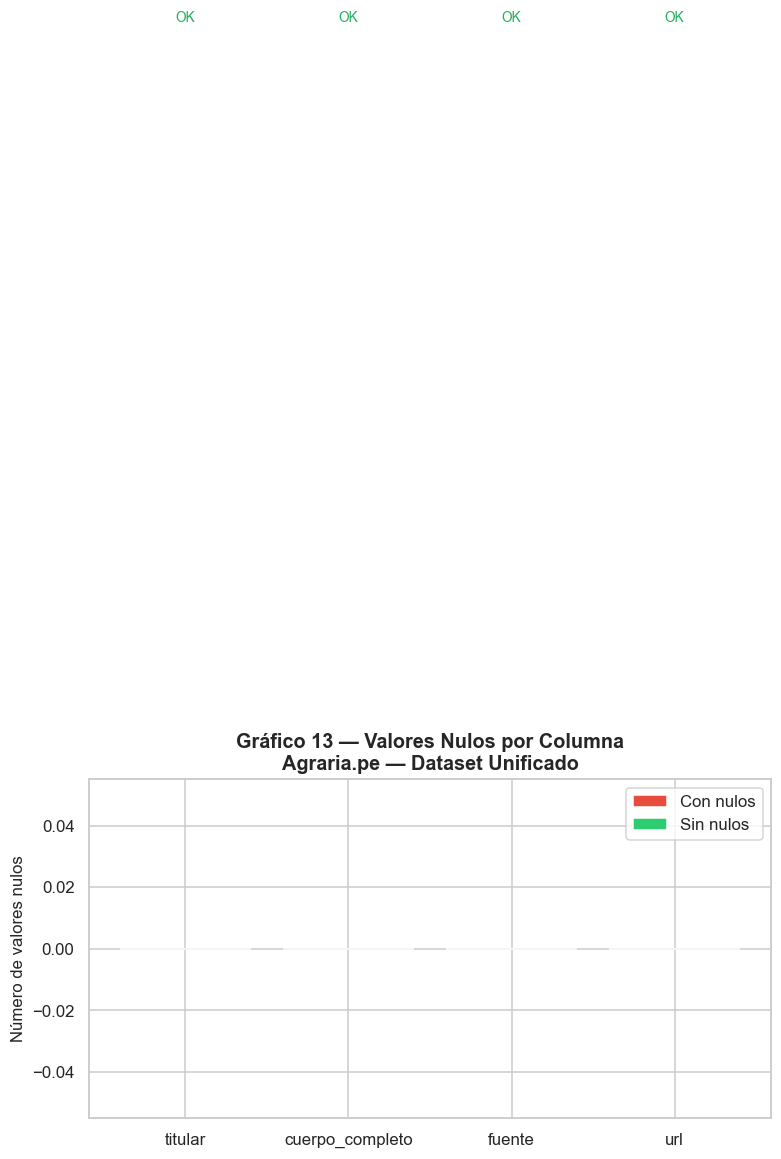

Guardado: pipeline/output/03_eda/act02_g13_nulos_agraria.png

  titular                  0 nulos (0.0%)  OK
  cuerpo_completo          0 nulos (0.0%)  OK
  fuente                   0 nulos (0.0%)  OK
  url                      0 nulos (0.0%)  OK


In [28]:
# ── GRAFICO 13 ────────────────────────────────────────────────────────────
cols_texto = [c for c in ['titular','cuerpo_completo','fuente','url'] if c in df_agr.columns]
nulos13 = df_agr[cols_texto].isnull().sum()
pct13   = (nulos13 / len(df_agr) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
colors13 = ['#e74c3c' if v > 0 else '#2ecc71' for v in nulos13.values]
bars13 = ax.bar(nulos13.index, nulos13.values, color=colors13, edgecolor='white')
ax.set_ylabel('Número de valores nulos', fontsize=11)
ax.set_title('Gráfico 13 — Valores Nulos por Columna\n'
             'Agraria.pe — Dataset Unificado', fontsize=13, fontweight='bold')
for bar, val, pct in zip(bars13, nulos13.values, pct13.values):
    label = f'{val}\n({pct}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=9, color=color)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Con nulos'),
                   Patch(facecolor='#2ecc71', label='Sin nulos')])
plt.tight_layout()
g13 = OUTPUT['eda'] + 'act02_g13_nulos_agraria.png'
plt.savefig(g13, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g13)
print()
for col, n, p in zip(nulos13.index, nulos13.values, pct13.values):
    print(f'  {col:<20} {n:>5} nulos ({p:.1f}%)  {"REQUIERE LIMPIEZA" if n>0 else "OK"}')


### Interpretación — Gráfico 13

**Qué muestra:** El número de valores nulos en cada columna del dataset de noticias.

**Implicación para el pipeline:** Las noticias sin `titular` son inutilizables y se eliminarán en la Actividad 5. Las noticias sin `cuerpo_completo` pueden conservarse para el conteo mensual pero no para el análisis NLP.

**Implicación para el modelo:** Para la Fase 1 solo se necesita el conteo mensual, por lo que los nulos en `cuerpo_completo` no afectan el dataset maestro. Sin embargo, deben documentarse ahora para anticipar el trabajo de la Fase 2 (BETO).


## 4.6 Exportación Agraria raw


In [29]:
out_a = OUTPUT['lectura'] + 'agraria_raw.csv'
df_agr.to_csv(out_a, index=False, encoding='utf-8-sig')
print('Exportado:', out_a, '| Shape:', df_agr.shape)


Exportado: pipeline/output/02_lectura/agraria_raw.csv | Shape: (528, 9)


---
# 5. Resumen de la Actividad 2


In [30]:
print('=' * 70)
print('  ACTIVIDAD 2 COMPLETADA — RESUMEN DE HALLAZGOS')
print('=' * 70)
print()
print('MIDAGRI:')
print('  - Contiene multiples cultivos. Solo se usara LIMON (Actividad 5).')
print('  - Rango 2016-2025 disponible. Pipeline usa 2021-2025.')
print('  - Verificar cobertura por departamento en Actividad 4.')
print()
print('INDECI:')
print('  - Multiples tipos de fenomenos. Solo se usaran los hidrometeorologicos (Actividad 5).')
print('  - Shapefiles disponibles 2021-2023. Resumenes Excel hasta 2024.')
print('  - Campos de texto conservados para Fase 2 (BETO).')
print()
print('NASA POWER:')
print('  - Archivo crudo documentado (nasapowercrudo/): formato nativo no legible por pandas.')
print('  - 102 CSVs pre-procesados por compañero en Google Colab (nasapower/).')
print('  - Solo ALLSKY_SFC_SW_DWN tiene nulos (meses futuros sep-dic 2025).')
print('  - PRECTOTCORR esta en mm/dia. Se convertira a mm/mes en Actividad 5.')
print()
print('AGRARIA.PE:')
print('  - 5 CSVs anuales unificados.')
print('  - Algunos nulos en cuerpo_completo (no critico para Fase 1).')
print('  - Texto conservado integro para Fase 2 (BETO).')
print()
print('Graficos generados (13 en total):')
import glob as gl
graficos = sorted(gl.glob(OUTPUT['eda'] + 'act02_*.png'))
for g in graficos:
    print(f'  {os.path.basename(g)}')
print()
print('Proximos pasos:')
print('  Actividad 3 -> EDA por fuente')
print('  Actividad 4 -> Calidad de datos')


  ACTIVIDAD 2 COMPLETADA — RESUMEN DE HALLAZGOS

MIDAGRI:
  - Contiene multiples cultivos. Solo se usara LIMON (Actividad 5).
  - Rango 2016-2025 disponible. Pipeline usa 2021-2025.
  - Verificar cobertura por departamento en Actividad 4.

INDECI:
  - Multiples tipos de fenomenos. Solo se usaran los hidrometeorologicos (Actividad 5).
  - Shapefiles disponibles 2021-2023. Resumenes Excel hasta 2024.
  - Campos de texto conservados para Fase 2 (BETO).

NASA POWER:
  - Archivo crudo documentado (nasapowercrudo/): formato nativo no legible por pandas.
  - 102 CSVs pre-procesados por compañero en Google Colab (nasapower/).
  - Solo ALLSKY_SFC_SW_DWN tiene nulos (meses futuros sep-dic 2025).
  - PRECTOTCORR esta en mm/dia. Se convertira a mm/mes en Actividad 5.

AGRARIA.PE:
  - 5 CSVs anuales unificados.
  - Algunos nulos en cuerpo_completo (no critico para Fase 1).
  - Texto conservado integro para Fase 2 (BETO).

Graficos generados (13 en total):
  act02_g10_nulos_nasa.png
  act02_g11_noti